# Proyecto

1. **Data Collect - Overview**
2. **Data Quality y Cleaning**
3. **Preparación para el EDA**
4. **EDA del dataset completo**
5. **Data Transformation: Producto P009**
6. **Insights: análisis del Producto P009**


## 1. Data Collect y overview inicial

En esta sección se visualiza la estructura inicial del dataset como primeras filas, información general y dimensiones.


In [1]:
import pandas as pd

df=pd.read_csv("demand_forecasting.csv")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [5]:
df.shape

(76000, 16)

## 2. Data Quality & Cleaning

Esta sección se enfoca únicamente en revisar y limpiar la calidad de los datos como tipos de datos, nombres de columnas, duplicados y nulos.


### 2.1 Revisión de tipos de datos y rango temporal

Se convierte la columna de fecha y se revisan los tipos de variables disponibles.


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
print(f"Desde: {df['Date'].min()}  Hasta: {df['Date'].max()}")

Desde: 2022-01-01 00:00:00  Hasta: 2024-01-30 00:00:00


In [8]:
df.dtypes

Date                  datetime64[us]
Store ID                         str
Product ID                       str
Category                         str
Region                           str
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition                str
Promotion                      int64
Competitor Pricing           float64
Seasonality                      str
Epidemic                       int64
Demand                         int64
dtype: object

### 2.2 Revisión de valores únicos, duplicados y nulos

Se revisan valores únicos, registros duplicados y presencia de datos faltantes.


In [9]:
df.nunique().sort_values(ascending=True)

Epidemic                  2
Promotion                 2
Region                    4
Seasonality               4
Weather Condition         4
Store ID                  5
Category                  5
Discount                  6
Product ID               20
Units Sold              330
Demand                  340
Date                    760
Units Ordered           996
Inventory Level        1426
Price                 15396
Competitor Pricing    15963
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum(axis=1).sort_values(ascending=False).head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

### 2.3 Limpieza de nombres, tipos y duplicados

Se estandarizan nombres de columnas, se ajustan tipos categóricos y se eliminan duplicados.


In [13]:
renombrar = {
            "Date":"date",
             "Store ID":"store_id",
             "Product ID" : "product_id",
             "Category":"category",
             "Region": "region",
             "Inventory Level": "inventory_level",
             "Units Sold": "units_sold",
             "Units Ordered": "units_ordered",
             "Price": "price",
             "Discount": "discount",
             "Weather Condition": "weather_condition",
             "Promotion": "is_promotion",
             "Competitor Pricing": "competitor_pricing",
             "Seasonality": "seasonality",
              "Epidemic":  "is_epidemic",
             "Demand" : "demand"
}
df.rename(columns=renombrar, inplace=True)
print(list(df.columns))

['date', 'store_id', 'product_id', 'category', 'region', 'inventory_level', 'units_sold', 'units_ordered', 'price', 'discount', 'weather_condition', 'is_promotion', 'competitor_pricing', 'seasonality', 'is_epidemic', 'demand']


In [14]:
df["is_promotion"] = df["is_promotion"].astype('category')
df["is_epidemic"] = df["is_epidemic"].astype('category')

In [15]:
df.dtypes

date                  datetime64[us]
store_id                         str
product_id                       str
category                         str
region                           str
inventory_level                int64
units_sold                     int64
units_ordered                  int64
price                        float64
discount                       int64
weather_condition                str
is_promotion                category
competitor_pricing           float64
seasonality                      str
is_epidemic                 category
demand                         int64
dtype: object

In [16]:
df.drop_duplicates(inplace=True)
print(f"Forma despues de eliminar duplicados: {df.shape}")

Forma despues de eliminar duplicados: (76000, 16)


In [17]:
df.isnull().sum(axis=1).sort_values(ascending=False).head(10)


0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

In [18]:
pct_nulos_fila = (df.isnull().sum(axis=1) / df.shape[1] * 100)
pct_nulos_fila.sort_values(ascending=False).head(10)

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
dtype: float64

## 3. Preparación para el EDA

Se crean variables auxiliares de fecha y se separan variables categóricas y numéricas para facilitar el análisis exploratorio.


In [19]:
# Agregar features 

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.day_name()
#df.drop('date', axis=1, inplace=True)
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,is_promotion,competitor_pricing,seasonality,is_epidemic,demand,year,month,day,day_of_week
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


In [20]:
# Analisis de variables categoricas y numericas
df_cat = df.select_dtypes(exclude=['number'])
df_num = df.select_dtypes(include=['number'])

print(f"Variables categóricas: {list(df_cat.columns)}")
print(f"Forma: {df_cat.shape}")

print(f"Variables numéricas: {list(df_num.columns)}")
print(f"Forma: {df_num.shape}")

Variables categóricas: ['date', 'store_id', 'product_id', 'category', 'region', 'weather_condition', 'is_promotion', 'seasonality', 'is_epidemic', 'day_of_week']
Forma: (76000, 10)
Variables numéricas: ['inventory_level', 'units_sold', 'units_ordered', 'price', 'discount', 'competitor_pricing', 'demand', 'year', 'month', 'day']
Forma: (76000, 10)


### 3.1 Respaldo de dataframes preparados

Se guardan los subconjuntos numérico y categórico para reutilizarlos en las siguientes secciones.


In [21]:
# Importar df_cat y df_num a pickle
df_num.to_pickle("df_num.pkl")
df_cat.to_pickle("df_cat.pkl")

In [22]:
df_num = pd.read_pickle("df_num.pkl")
df_cat = pd.read_pickle("df_cat.pkl")

# Combino numéricas y categóricas
df = pd.concat([df_cat, df_num], axis=1)

## 4. EDA del dataset completo

En esta sección se analiza el dataset completo. Se divide en análisis univariado y bivariado


### 4.1 Análisis univariado — variables categóricas

Frecuencias, proporciones y distribución de variables categóricas.


In [23]:
df_cat.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               76000 non-null  datetime64[us]
 1   store_id           76000 non-null  str           
 2   product_id         76000 non-null  str           
 3   category           76000 non-null  str           
 4   region             76000 non-null  str           
 5   weather_condition  76000 non-null  str           
 6   is_promotion       76000 non-null  category      
 7   seasonality        76000 non-null  str           
 8   is_epidemic        76000 non-null  category      
 9   day_of_week        76000 non-null  str           
dtypes: category(2), datetime64[us](1), str(7)
memory usage: 4.8 MB


In [24]:
df_cat['store_id'].value_counts()

store_id
S001    15200
S002    15200
S003    15200
S004    15200
S005    15200
Name: count, dtype: int64

In [25]:
df_cat['product_id'].value_counts()

product_id
P0001    3800
P0002    3800
P0003    3800
P0004    3800
P0005    3800
P0006    3800
P0007    3800
P0008    3800
P0009    3800
P0010    3800
P0011    3800
P0012    3800
P0013    3800
P0014    3800
P0015    3800
P0016    3800
P0017    3800
P0018    3800
P0019    3800
P0020    3800
Name: count, dtype: int64

In [26]:
df_cat['category'].value_counts(normalize=True)

category
Groceries      0.40
Furniture      0.18
Clothing       0.16
Toys           0.14
Electronics    0.12
Name: proportion, dtype: float64

In [27]:
df_cat['region'].value_counts(normalize=True)

region
North    0.4
South    0.2
East     0.2
West     0.2
Name: proportion, dtype: float64

In [28]:
df_cat['weather_condition'].value_counts(normalize=True)

weather_condition
Cloudy    0.320526
Sunny     0.302368
Rainy     0.230263
Snowy     0.146842
Name: proportion, dtype: float64

In [29]:
df_cat['is_epidemic'].value_counts(normalize=True)

is_epidemic
0    0.8
1    0.2
Name: proportion, dtype: float64

In [30]:
df_cat['is_promotion'].value_counts(normalize=True)

is_promotion
0    0.671053
1    0.328947
Name: proportion, dtype: float64

In [31]:
df_cat['seasonality'].value_counts(normalize=True)

seasonality
Winter    0.276316
Spring    0.242105
Summer    0.242105
Autumn    0.239474
Name: proportion, dtype: float64

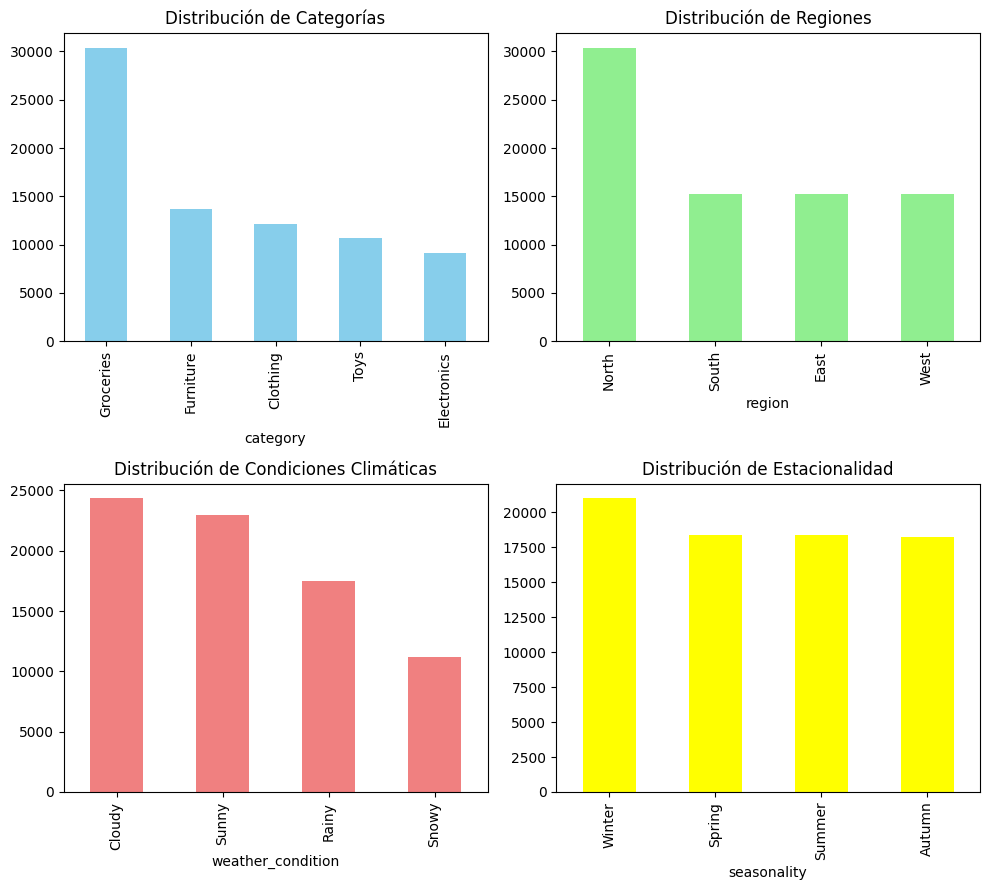

In [32]:
fig,axs = plt.subplots(2,2, figsize=(10,9))

df_cat['category'].value_counts().plot(kind='bar', ax=axs[0,0], title='Distribución de Categorías', color='skyblue')
df_cat['region'].value_counts().plot(kind='bar', ax=axs[0,1], title='Distribución de Regiones', color='lightgreen')
df_cat['weather_condition'].value_counts().plot(kind='bar', ax=axs[1,0], title='Distribución de Condiciones Climáticas', color='lightcoral')
df_cat['seasonality'].value_counts().plot(kind='bar', ax=axs[1,1], title='Distribución de Estacionalidad', color='yellow')
plt.tight_layout()

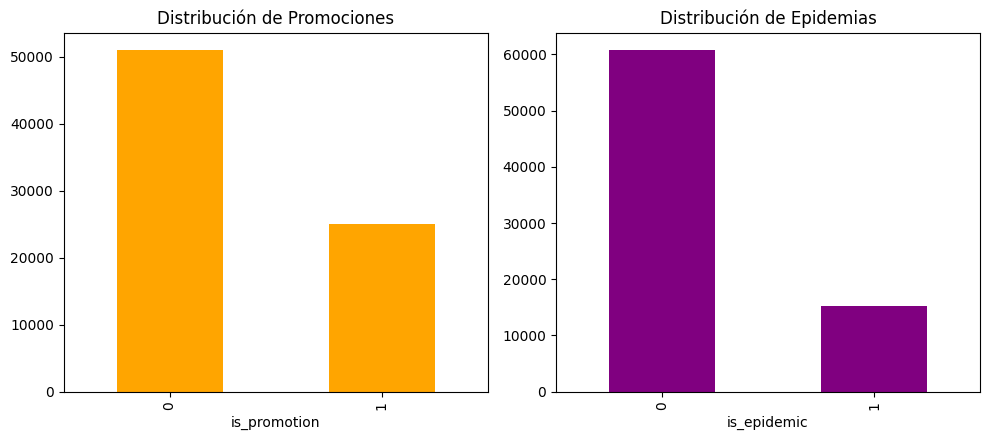

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

df_cat['is_promotion'].value_counts().plot(kind='bar', ax=axs[0], title='Distribución de Promociones', color='orange')
df_cat['is_epidemic'].value_counts().plot(kind='bar', ax=axs[1], title='Distribución de Epidemias', color='purple')

plt.tight_layout()
plt.show()

### 4.2 Análisis univariado — variables numéricas

Estadísticos descriptivos, histogramas, boxplots, percentiles y revisión de outliers generales del dataset.


In [34]:
df_num.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   inventory_level     76000 non-null  int64  
 1   units_sold          76000 non-null  int64  
 2   units_ordered       76000 non-null  int64  
 3   price               76000 non-null  float64
 4   discount            76000 non-null  int64  
 5   competitor_pricing  76000 non-null  float64
 6   demand              76000 non-null  int64  
 7   year                76000 non-null  int32  
 8   month               76000 non-null  int32  
 9   day                 76000 non-null  int32  
dtypes: float64(2), int32(3), int64(5)
memory usage: 4.9 MB


In [35]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
inventory_level,76000.0,301.062842,226.510161,0.00,136.0000,227.0,408.0000,2267.00
units_sold,76000.0,88.827316,43.994525,0.00,58.0000,84.0,114.0000,426.00
units_ordered,76000.0,89.090645,162.404627,0.00,0.0000,0.0,121.0000,1616.00
price,76000.0,67.726028,39.377899,4.74,31.9975,64.5,95.8300,228.03
discount,76000.0,9.087039,7.475781,0.00,5.0000,10.0,10.0000,25.00
competitor_pricing,76000.0,69.454029,40.943818,4.29,32.6200,65.7,97.9325,261.22
demand,76000.0,104.317158,46.964801,4.00,71.0000,100.0,133.0000,430.00
year,76000.0,2022.559211,0.570479,2022.00,2022.0000,2023.0,2023.0000,2024.00
month,76000.0,6.307895,3.546325,1.00,3.0000,6.0,9.0000,12.00
day,76000.0,15.711842,8.790894,1.00,8.0000,16.0,23.0000,31.00


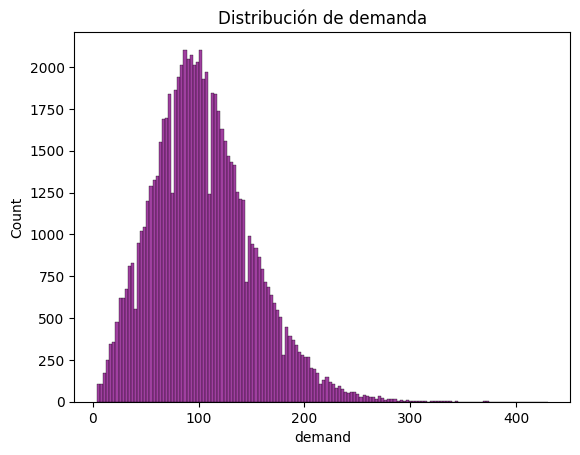

In [36]:
fig, ax = plt.subplots()
sns.histplot(data=df_num, x='demand', color="purple")
ax.set_title("Distribución de demanda")
plt.show()

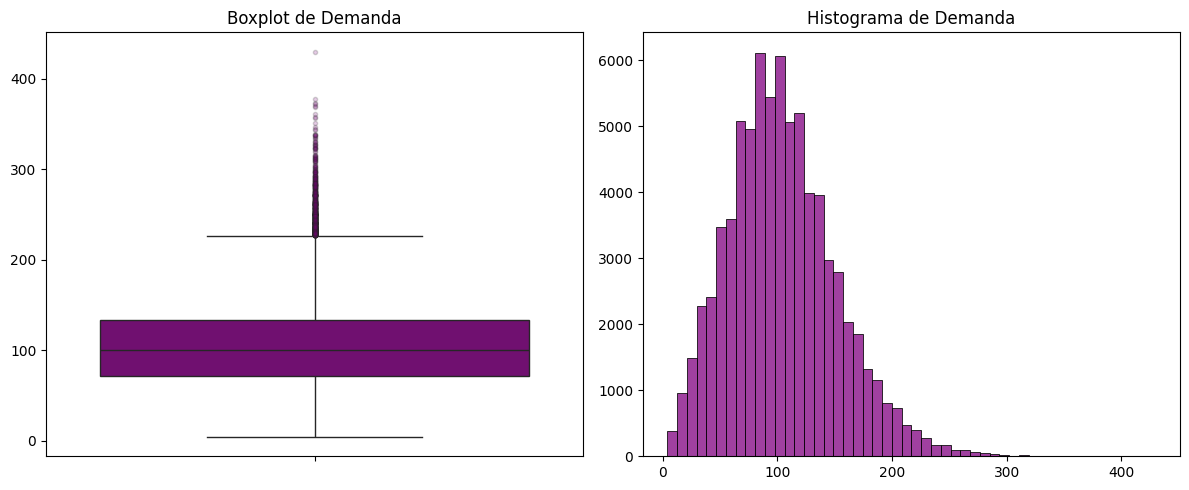

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_num, y='demand', ax=axes[0], color='purple',
    flierprops=dict(marker='o', markerfacecolor='purple', alpha=0.2, markersize=3))
sns.histplot(data=df_num, x='demand', bins=50, ax=axes[1], color='purple')
axes[0].set_title('Boxplot de Demanda')
axes[1].set_title('Histograma de Demanda')

axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')


plt.tight_layout()

In [38]:
print(f"Percentil 25: {df['demand'].quantile(0.25):.2f}")
print(f"Percentil 50: {df['demand'].quantile(0.50):.2f}")
print(f"Percentil 75: {df['demand'].quantile(0.75):.2f}")
print(f"Percentil 99: {df['demand'].quantile(0.99):.2f}")

percentiles = [1, 5, 10, 20, 25, 50, 75, 80, 90, 95, 97.5, 99, 99.9, 99.99, 100]
datos = [(p, df_num['demand'].quantile(p / 100)) for p in percentiles]
print(pd.DataFrame(datos, columns=["Percentil", "Valor"]).round(2))


Percentil 25: 71.00
Percentil 50: 100.00
Percentil 75: 133.00
Percentil 99: 234.00
    Percentil  Valor
0        1.00   17.0
1        5.00   34.0
2       10.00   47.0
3       20.00   65.0
4       25.00   71.0
5       50.00  100.0
6       75.00  133.0
7       80.00  141.0
8       90.00  166.0
9       95.00  188.0
10      97.50  208.0
11      99.00  234.0
12      99.90  295.0
13      99.99  357.4
14     100.00  430.0


In [39]:
q1 = df_num['demand'].quantile(0.25)
q3 = df_num['demand'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Cantidad de valores por debajo del límite inferior: {(df_num['demand'] < limite_inferior).sum()}")
print(f"Cantidad de valores por encima del límite superior: {(df_num['demand'] > limite_superior).sum()}")

Q1: 71.00
Q3: 133.00
IQR: 62.00
Limite inferior: -22.00
Limite superior: 226.00
Cantidad de valores por debajo del límite inferior: 0
Cantidad de valores por encima del límite superior: 986


In [40]:
condicion_outliers = (df_num['demand'] < limite_inferior) | (df_num['demand'] > limite_superior)
outliers = df_num[condicion_outliers]['demand'].sort_values(ascending=True)
print(f"Cantidad total de outliers: {outliers.shape[0]}")
print(outliers)

Cantidad total de outliers: 986
2672     227
353      227
56353    227
3720     227
55852    227
        ... 
60261    370
53415    372
21885    373
21915    378
54387    430
Name: demand, Length: 986, dtype: int64


In [41]:
def std_outliers(data, threshold=3):
    mu = data.mean()
    std = data.std()
    lim_superior = mu + threshold * std
    lim_inferior = mu - threshold * std
    outliers = data[(data < lim_inferior) | (data > lim_superior)]
    print(f"Media: {mu:.2f}")
    print(f"Desviación estándar: {std:.2f}")
    print(f"Limite inferior: {lim_inferior:.2f}")
    print(f"Limite superior: {lim_superior:.2f}")
    print(f"Cantidad de outliers: {outliers.shape[0]}")
    return outliers.sort_values(ascending=False)


In [42]:
outliers_std = std_outliers(df_num['demand'], threshold=3)

Media: 104.32
Desviación estándar: 46.96
Limite inferior: -36.58
Limite superior: 245.21
Cantidad de outliers: 517


In [43]:
def outliers_zscore(data, threshold=3):
    """Detecta outliers usando Z-score."""
    mu = data.mean()
    std = data.std()
    resultados = []
    for valor in data:
        z = (valor - mu) / std
        if np.abs(z) > threshold:
            resultados.append({"valor": valor, "zscore": round(z, 3)})
    df_outliers = pd.DataFrame(resultados)
    if len(df_outliers) > 0:
        df_outliers = df_outliers.sort_values("zscore", ascending=False)
    print(f"Outliers con |z| > {threshold}: {len(df_outliers)}")
    return df_outliers

In [44]:
outliers_zscore(df_num['demand'], threshold=3)

Outliers con |z| > 3: 517


,valor,zscore
351,430,6.935
146,378,5.827
145,373,5.721
330,372,5.700
468,370,5.657
...,...,...
385,246,3.017
105,246,3.017
441,246,3.017
126,246,3.017


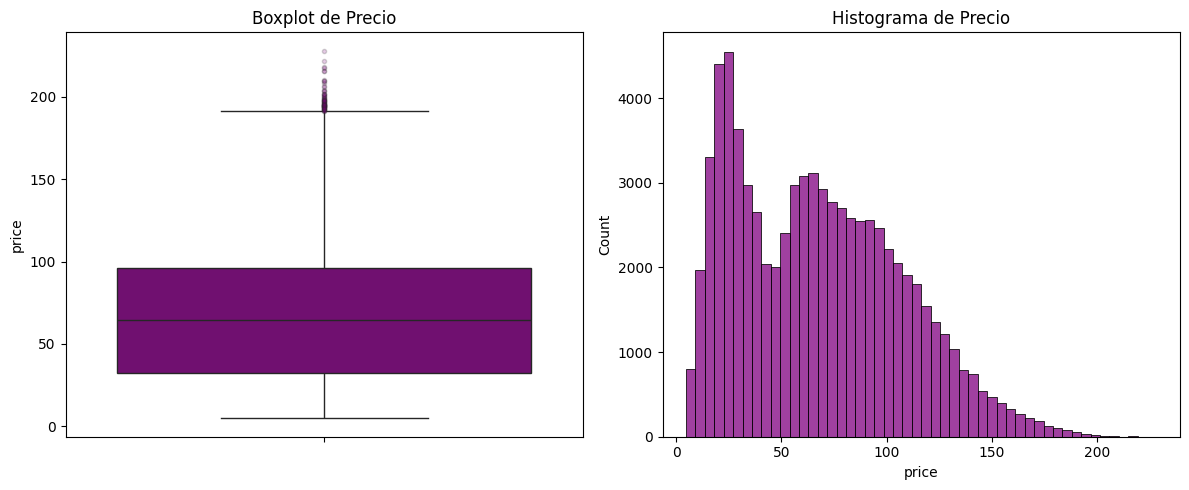

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_num, y='price', ax=axes[0], color='purple',
    flierprops=dict(marker='o', markerfacecolor='purple', alpha=0.2, markersize=3))
sns.histplot(data=df_num, x='price', bins=50, ax=axes[1], color='purple')
axes[0].set_title('Boxplot de Precio')
axes[1].set_title('Histograma de Precio')

plt.tight_layout()

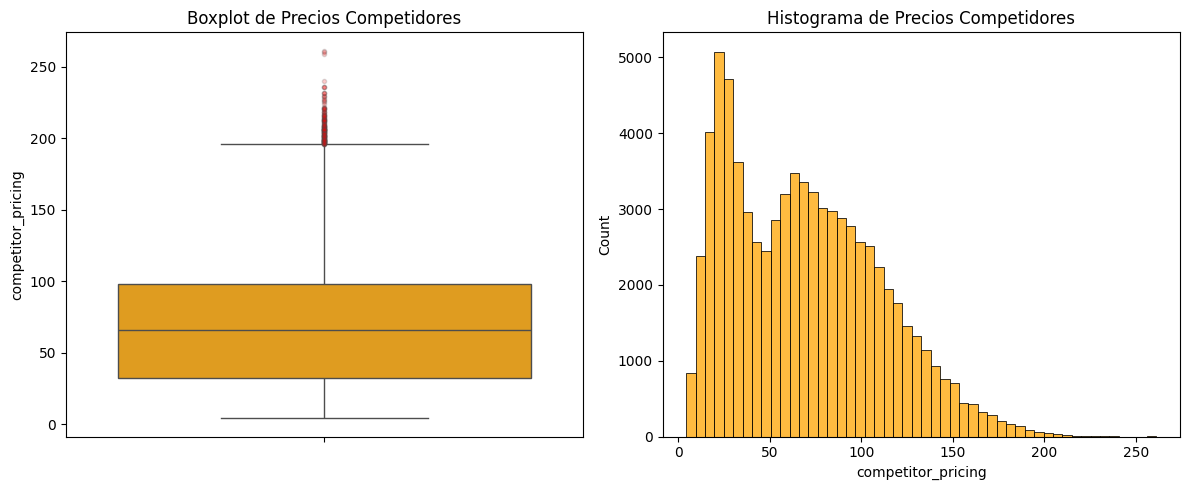

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_num, y='competitor_pricing', ax=axes[0], color='orange',
    flierprops=dict(marker='o', markerfacecolor='red', alpha=0.2, markersize=3))
sns.histplot(data=df_num, x='competitor_pricing', bins=50, ax=axes[1], color='orange')
axes[0].set_title('Boxplot de Precios Competidores')
axes[1].set_title('Histograma de Precios Competidores')

plt.tight_layout()

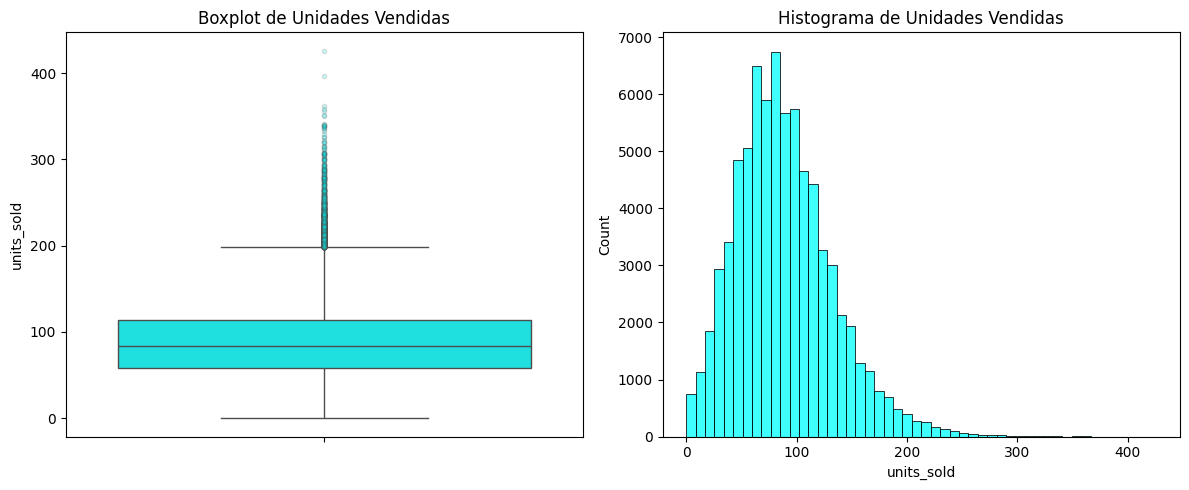

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_num, y='units_sold', ax=axes[0], color='cyan',
    flierprops=dict(marker='o', markerfacecolor='cyan', alpha=0.2, markersize=3))
sns.histplot(data=df_num, x='units_sold', bins=50, ax=axes[1], color='cyan')
axes[0].set_title('Boxplot de Unidades Vendidas')
axes[1].set_title('Histograma de Unidades Vendidas')

plt.tight_layout()

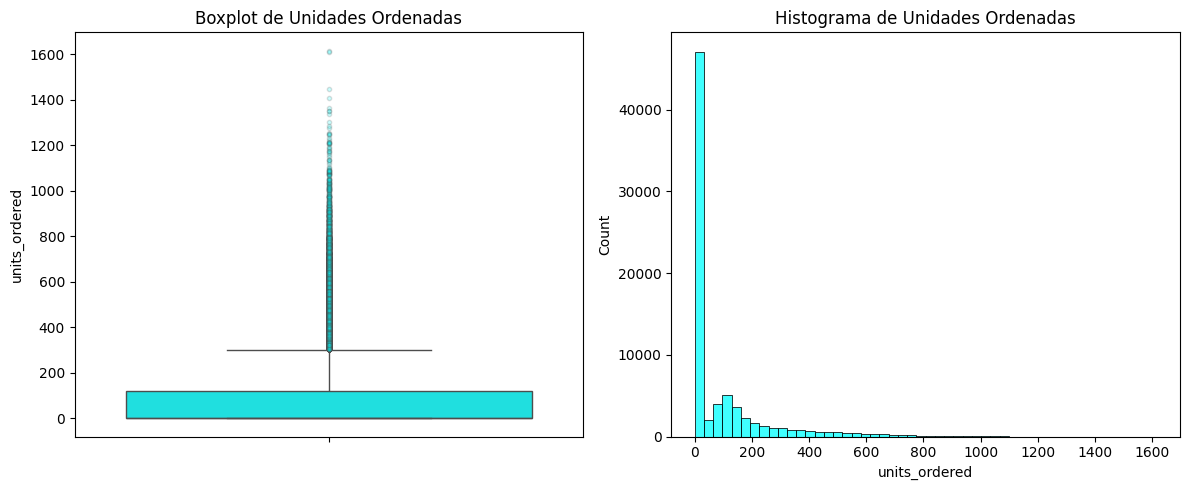

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_num, y='units_ordered', ax=axes[0], color='cyan',
    flierprops=dict(marker='o', markerfacecolor='cyan', alpha=0.2, markersize=3))
sns.histplot(data=df_num, x='units_ordered', bins=50, ax=axes[1], color='cyan')
axes[0].set_title('Boxplot de Unidades Ordenadas')
axes[1].set_title('Histograma de Unidades Ordenadas')

plt.tight_layout()

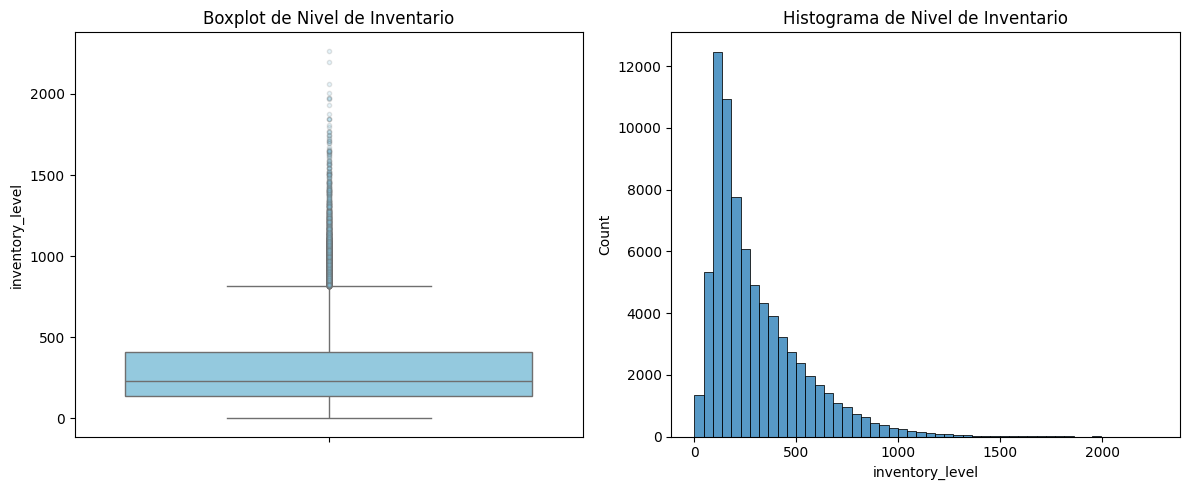

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_num, y='inventory_level', ax=axes[0], color='skyblue',
    flierprops=dict(marker='o', markerfacecolor='skyblue', alpha=0.2, markersize=3))
sns.histplot(data=df_num, x='inventory_level', bins=50, ax=axes[1])
axes[0].set_title('Boxplot de Nivel de Inventario')
axes[1].set_title('Histograma de Nivel de Inventario')

plt.tight_layout()

C:\Users\syrri\AppData\Local\Temp\ipykernel_39912\1194151517.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_num, x='discount', ax=ax, palette='rocket')


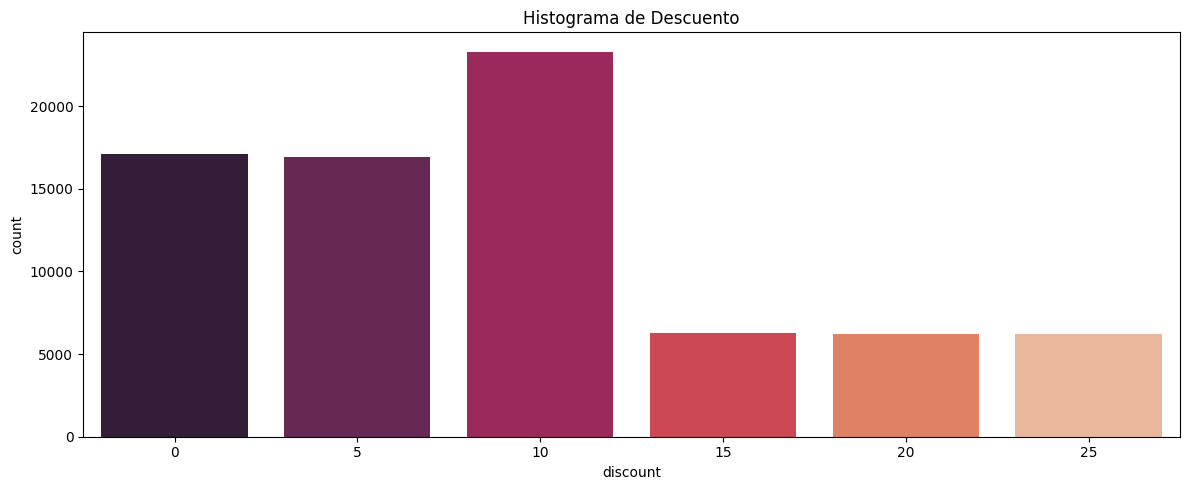

In [50]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.countplot(data=df_num, x='discount', ax=ax, palette='rocket')
ax.set_title('Boxplot de Descuento')
ax.set_title('Histograma de Descuento')

plt.tight_layout()

In [51]:
df_cat.mode()

,date,store_id,product_id,category,region,weather_condition,is_promotion,seasonality,is_epidemic,day_of_week
0,2022-01-01,S001,P0001,Groceries,North,Cloudy,0,Winter,0,Monday
1,2022-01-02,S002,P0002,NaN,NaN,NaN,NaN,NaN,NaN,Saturday
2,2022-01-03,S003,P0003,NaN,NaN,NaN,NaN,NaN,NaN,Sunday
3,2022-01-04,S004,P0004,NaN,NaN,NaN,NaN,NaN,NaN,Tuesday
4,2022-01-05,S005,P0005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
755,2024-01-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
756,2024-01-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
757,2024-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
758,2024-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
df_num.mode()

,inventory_level,units_sold,units_ordered,price,discount,competitor_pricing,demand,year,month,day
0,0.0,72.0,0.0,23.34,10.0,27.02,88.0,2022.0,1.0,1
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.0,NaN,2
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10


### 4.3 Análisis temporal general

Visualización de la demanda agregada por fecha, año, mes y día de semana.


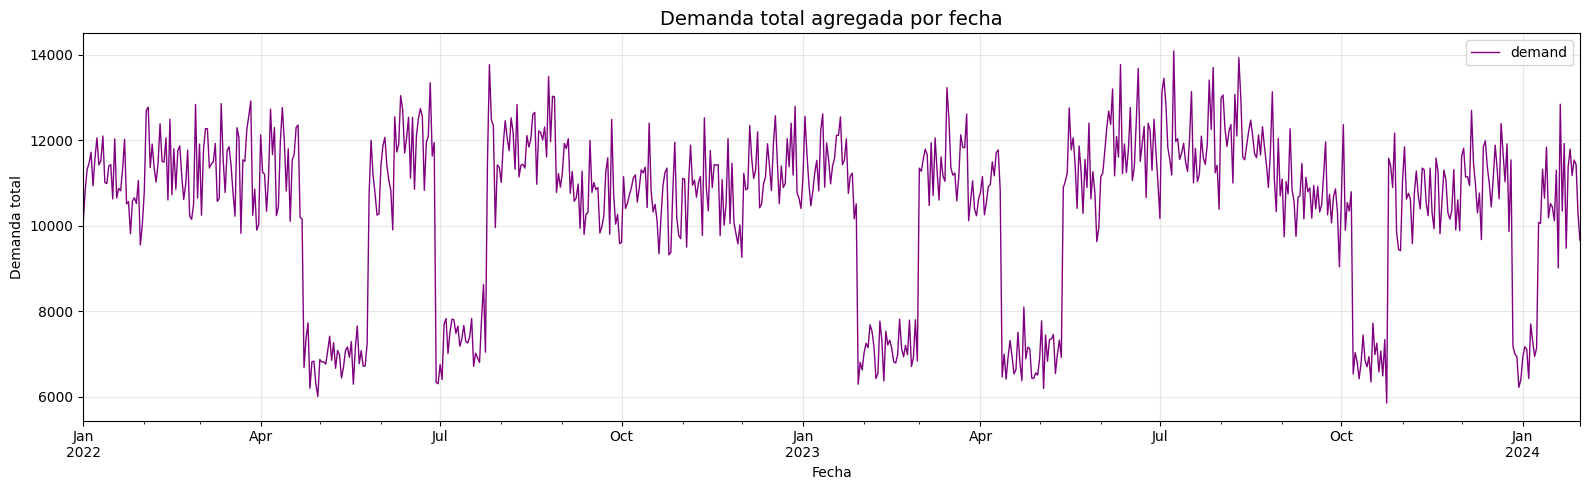

In [53]:
demand_diaria = df.groupby('date')['demand'].sum()

fig, ax = plt.subplots(figsize=(16, 5))
demand_diaria.plot(ax=ax, color='purple', linewidth=1)

ax.set_title('Demanda total agregada por fecha', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Demanda total')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

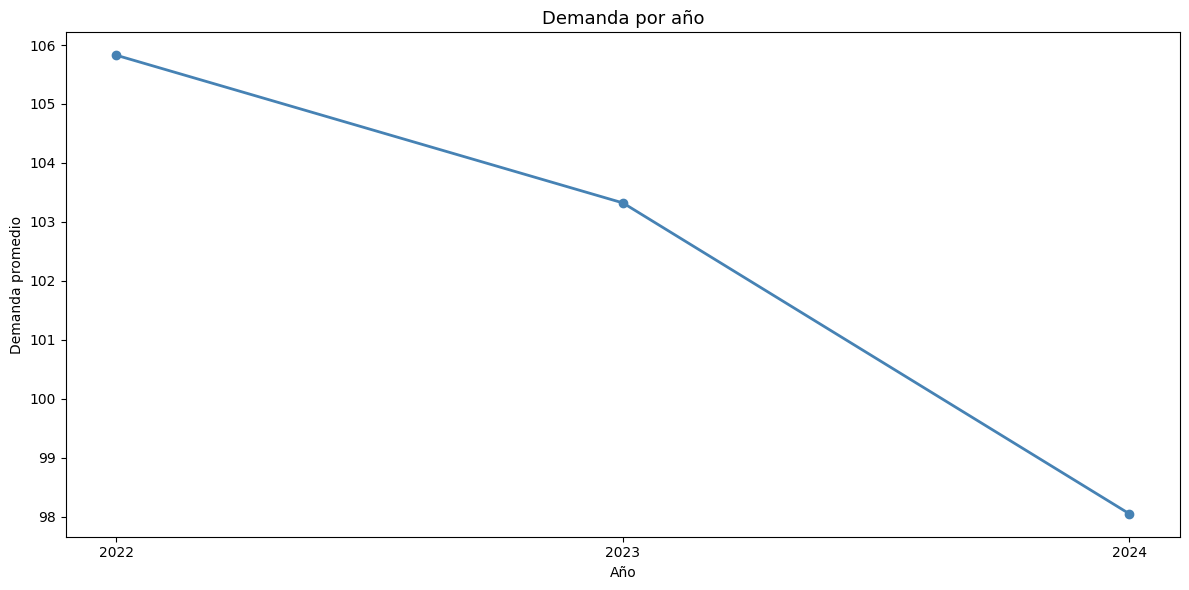

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))

year_stats = df.groupby('year')['demand'].mean().reset_index()
ax.plot(year_stats['year'], year_stats['demand'], marker='o', color='steelblue', linewidth=2)
ax.set_title('Demanda por año', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Demanda promedio')
ax.set_xticks(year_stats['year'])

plt.tight_layout()
plt.show()

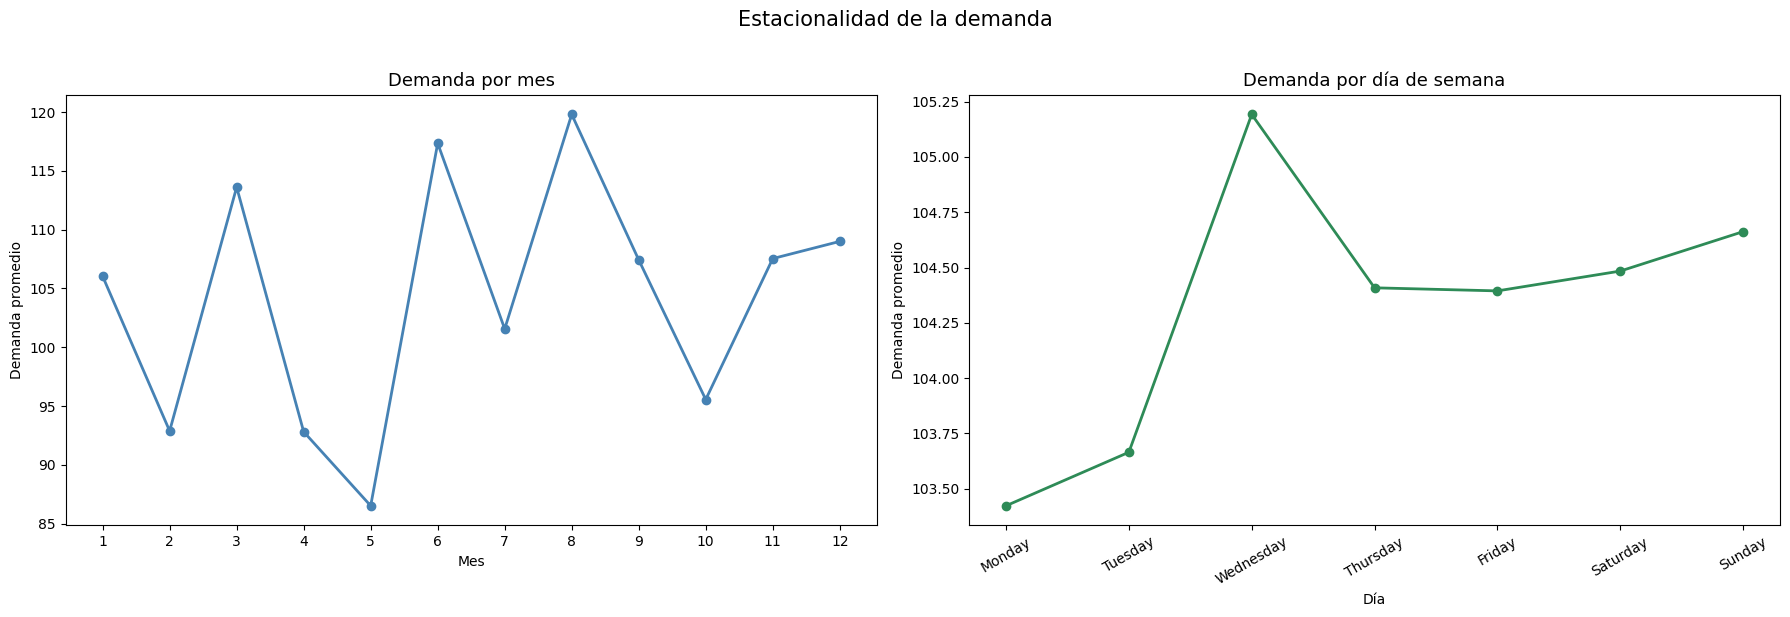

In [55]:
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
              'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Demanda por mes
mes_stats = df.groupby('month')['demand'].mean().reset_index()
axes[0].plot(mes_stats['month'], mes_stats['demand'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Demanda por mes', fontsize=13)
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Demanda promedio')
axes[0].set_xticks(mes_stats['month'])

# Demanda por día de semana
dia_stats = df.groupby('day_of_week')['demand'].mean().reindex(orden_dias).reset_index()
axes[1].plot(range(len(orden_dias)), dia_stats['demand'], marker='o', color='seagreen', linewidth=2)
axes[1].set_xticks(range(len(orden_dias)))
axes[1].set_xticklabels(orden_dias, rotation=30)
axes[1].set_title('Demanda por día de semana', fontsize=13)
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Demanda promedio')

plt.suptitle('Estacionalidad de la demanda', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Análisis bivariado — relación con la demanda

Relación de `demand` con variables numéricas, categóricas, producto, tienda, precio y correlaciones.


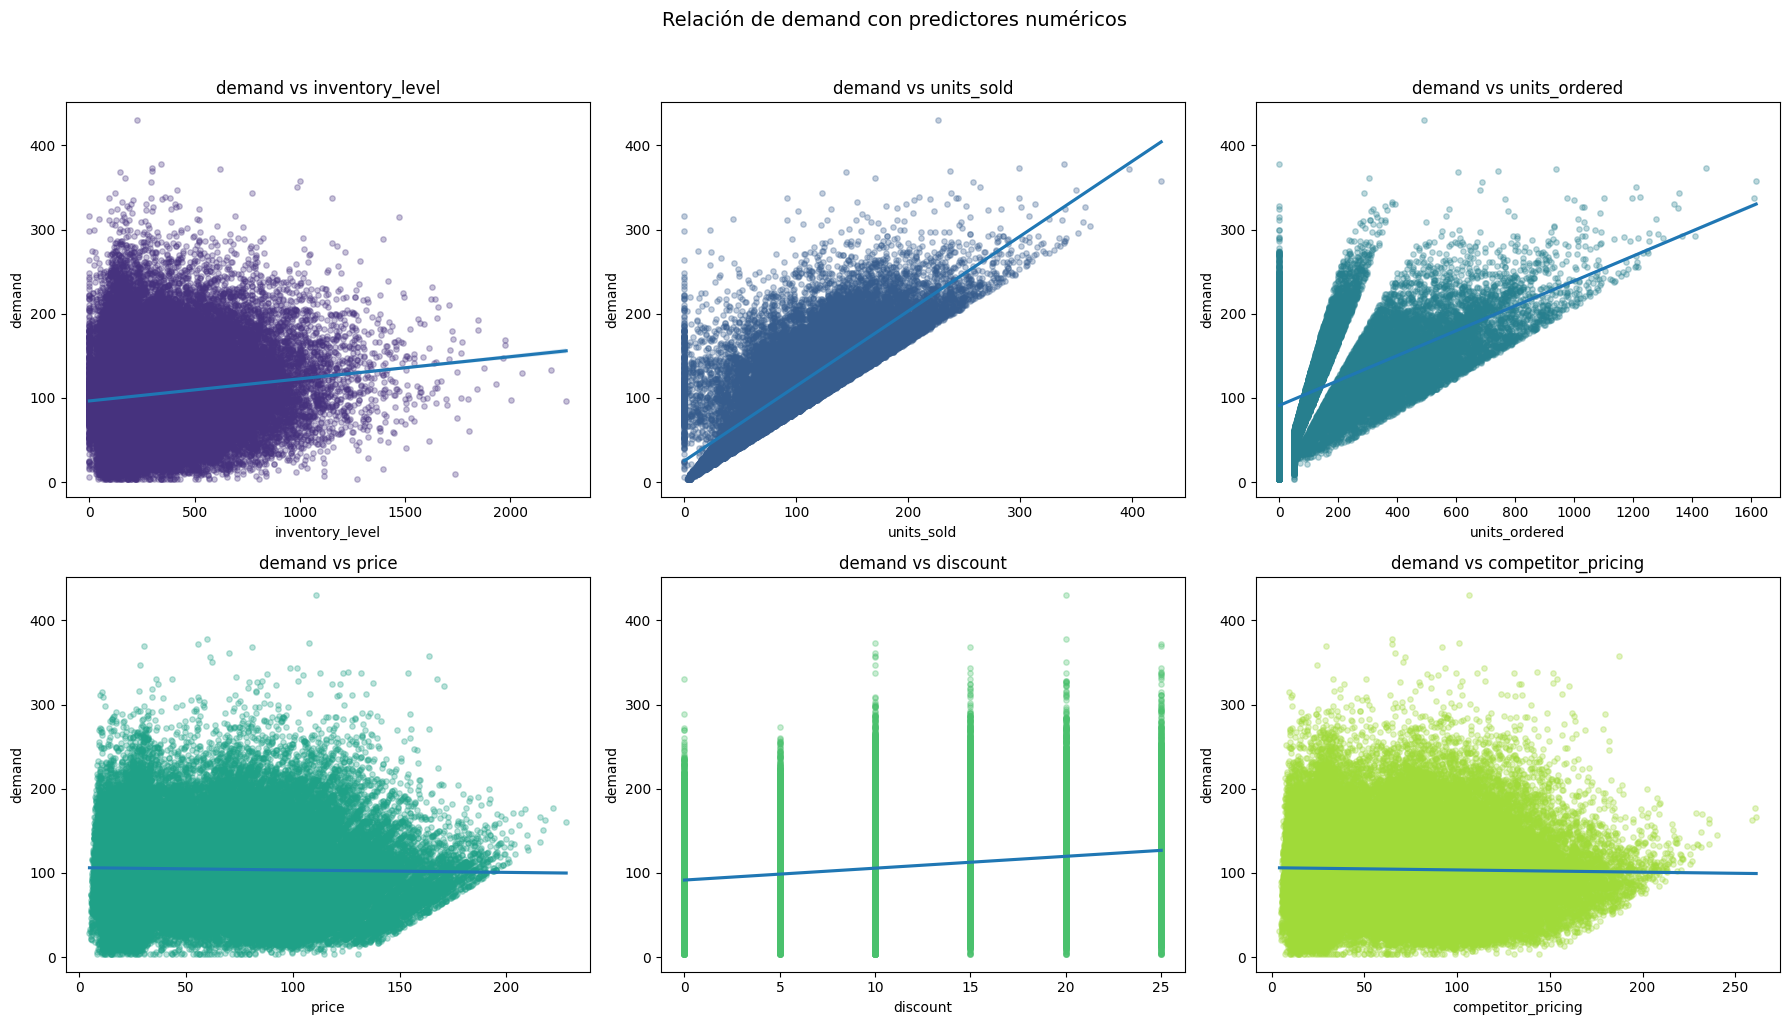

In [56]:
predictores_num = [c for c in df_num.columns if c not in ['demand', 'year', 'month', 'day']]
colores = sns.color_palette("viridis", 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col, color in zip(axes.flatten(), predictores_num, colores):
    sns.regplot(
        data=df_num, x=col, y='demand', ax=ax,
        scatter_kws={'alpha': 0.3, 's': 15, 'color': color}
    )
    ax.set_title(f'demand vs {col}')

plt.suptitle('Relación de demand con predictores numéricos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

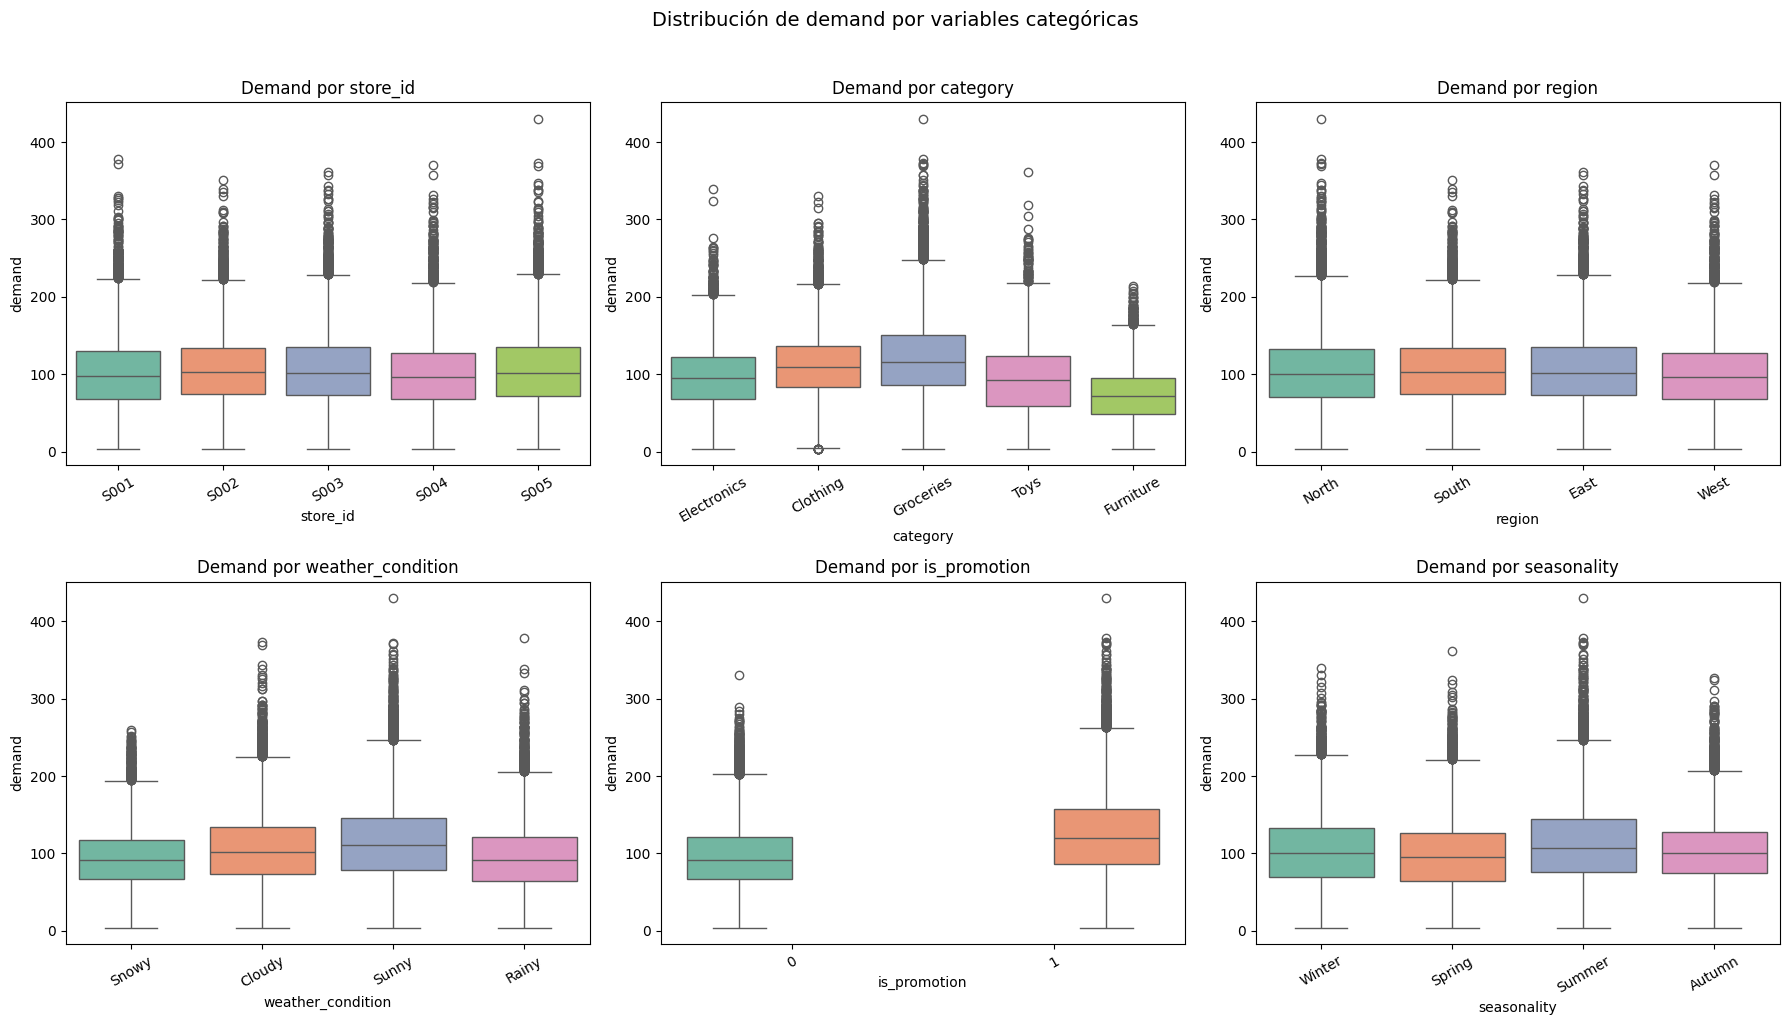

In [57]:
predictores_cat = [c for c in df_cat.columns if c not in ['day_of_week', 'date', 'product_id']]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), predictores_cat):
    sns.boxplot(
        data=df, x=col, y='demand', ax=ax,
        hue=col, palette='Set2', legend=False
    )
    ax.set_title(f'Demand por {col}')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de demand por variables categóricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

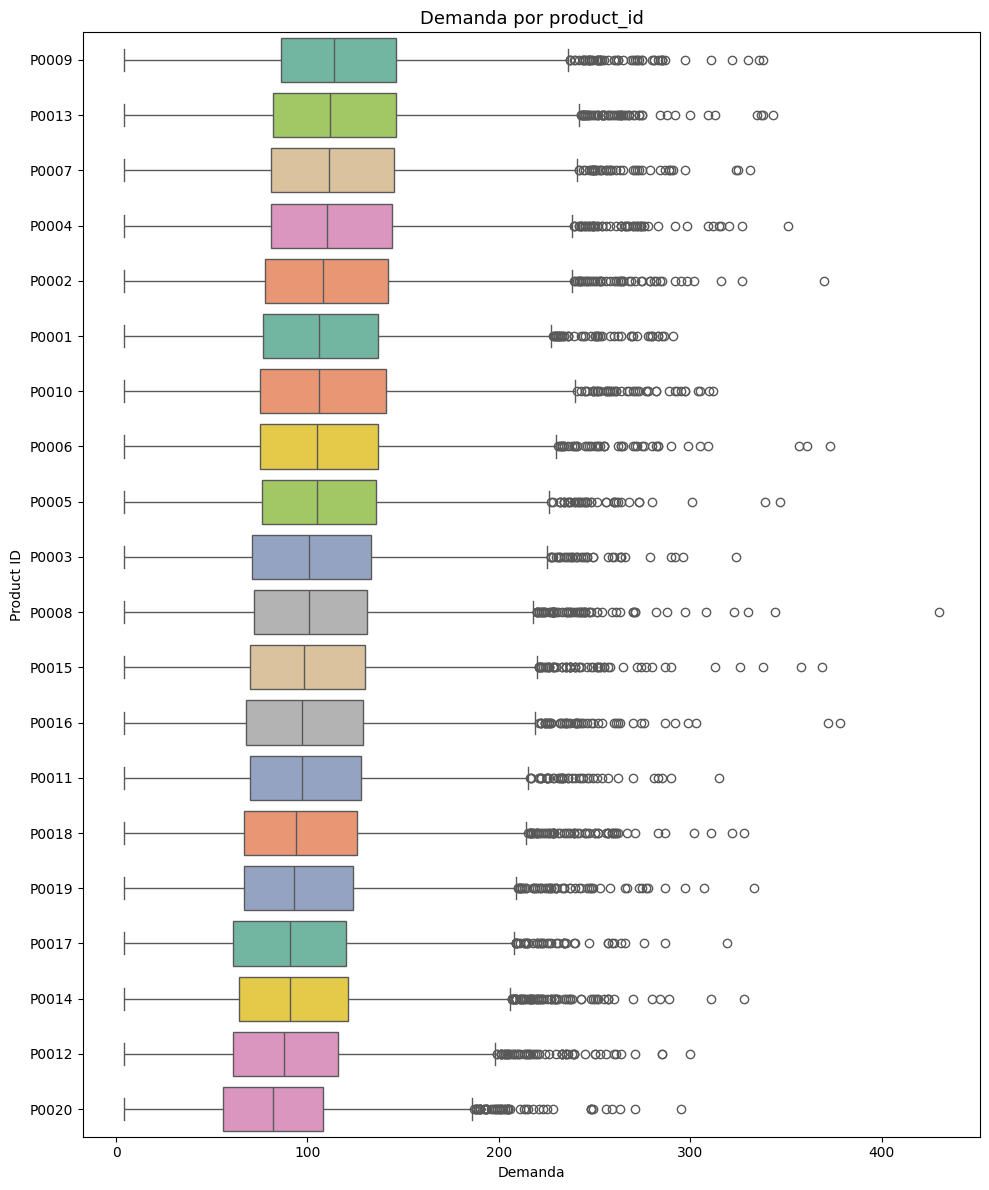

In [58]:
fig, ax = plt.subplots(figsize=(10, 12))
sns.boxplot(
    data=df, x='demand', y='product_id', ax=ax,
    hue='product_id', palette='Set2', legend=False,
    order=df.groupby('product_id')['demand'].median().sort_values(ascending=False).index
)
ax.set_title('Demanda por product_id', fontsize=13)
ax.set_xlabel('Demanda')
ax.set_ylabel('Product ID')
plt.tight_layout()
plt.show()

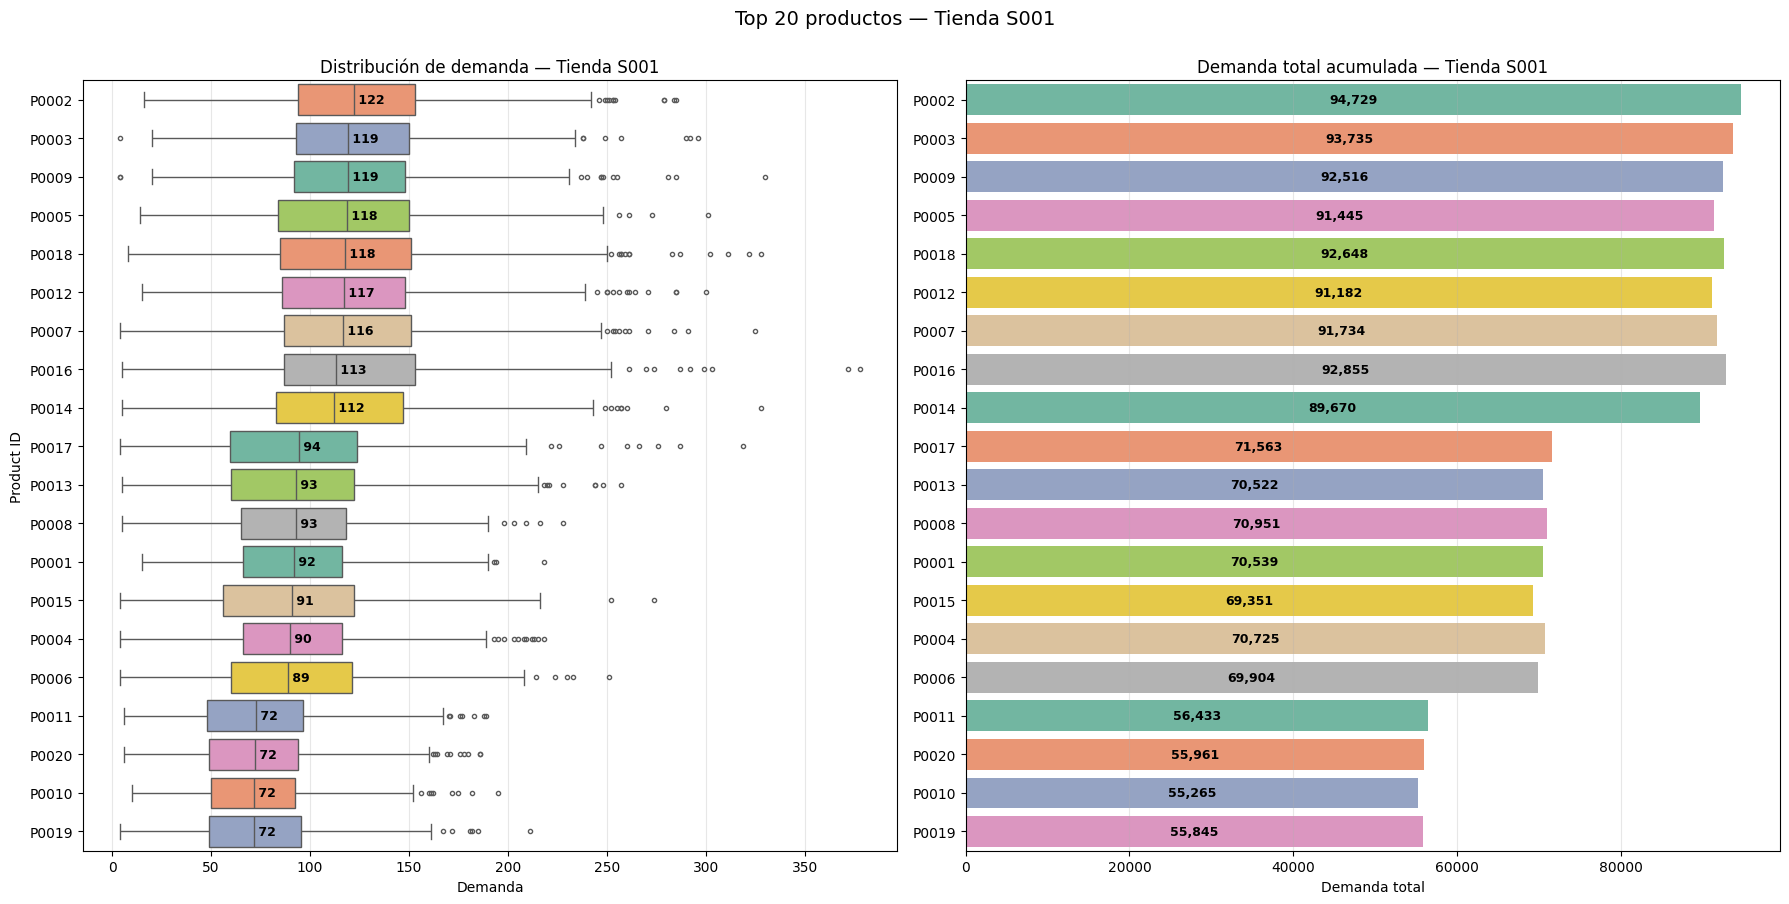

In [59]:
store = 'S001'
df_store = df[df['store_id'] == store]

top20 = (df_store.groupby('product_id')['demand']
         .median().sort_values(ascending=False).head(20).index)
df_top = df_store[df_store['product_id'].isin(top20)]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

sns.boxplot(data=df_top, x='demand', y='product_id',
            hue='product_id', palette='Set2', legend=False,
            order=top20, ax=axes[0], fliersize=3)
axes[0].set_title(f'Distribución de demanda — Tienda {store}', fontsize=12)
axes[0].set_xlabel('Demanda')
axes[0].set_ylabel('Product ID')
axes[0].grid(axis='x', alpha=0.3)

medians = df_top.groupby('product_id')['demand'].median().reindex(top20)
for i, (prod, med) in enumerate(medians.items()):
    axes[0].text(med, i, f' {med:.0f}',
                 va='center', ha='left',
                 fontsize=9, fontweight='bold', color='black')

total_demand = df_top.groupby('product_id')['demand'].sum().reindex(top20)
sns.barplot(x=total_demand.values, y=total_demand.index,
            hue=total_demand.index, palette='Set2', legend=False,
            ax=axes[1])
axes[1].set_title(f'Demanda total acumulada — Tienda {store}', fontsize=12)
axes[1].set_xlabel('Demanda total')
axes[1].set_ylabel('')
axes[1].grid(axis='x', alpha=0.3)

for i, val in enumerate(total_demand.values):
    axes[1].text(val / 2, i, f'{val:,.0f}',
                 va='center', ha='center',
                 fontsize=9, fontweight='bold', color='black')

axes[1].set_xlim(0, total_demand.max() * 1.05)

plt.suptitle(f'Top 20 productos — Tienda {store}', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

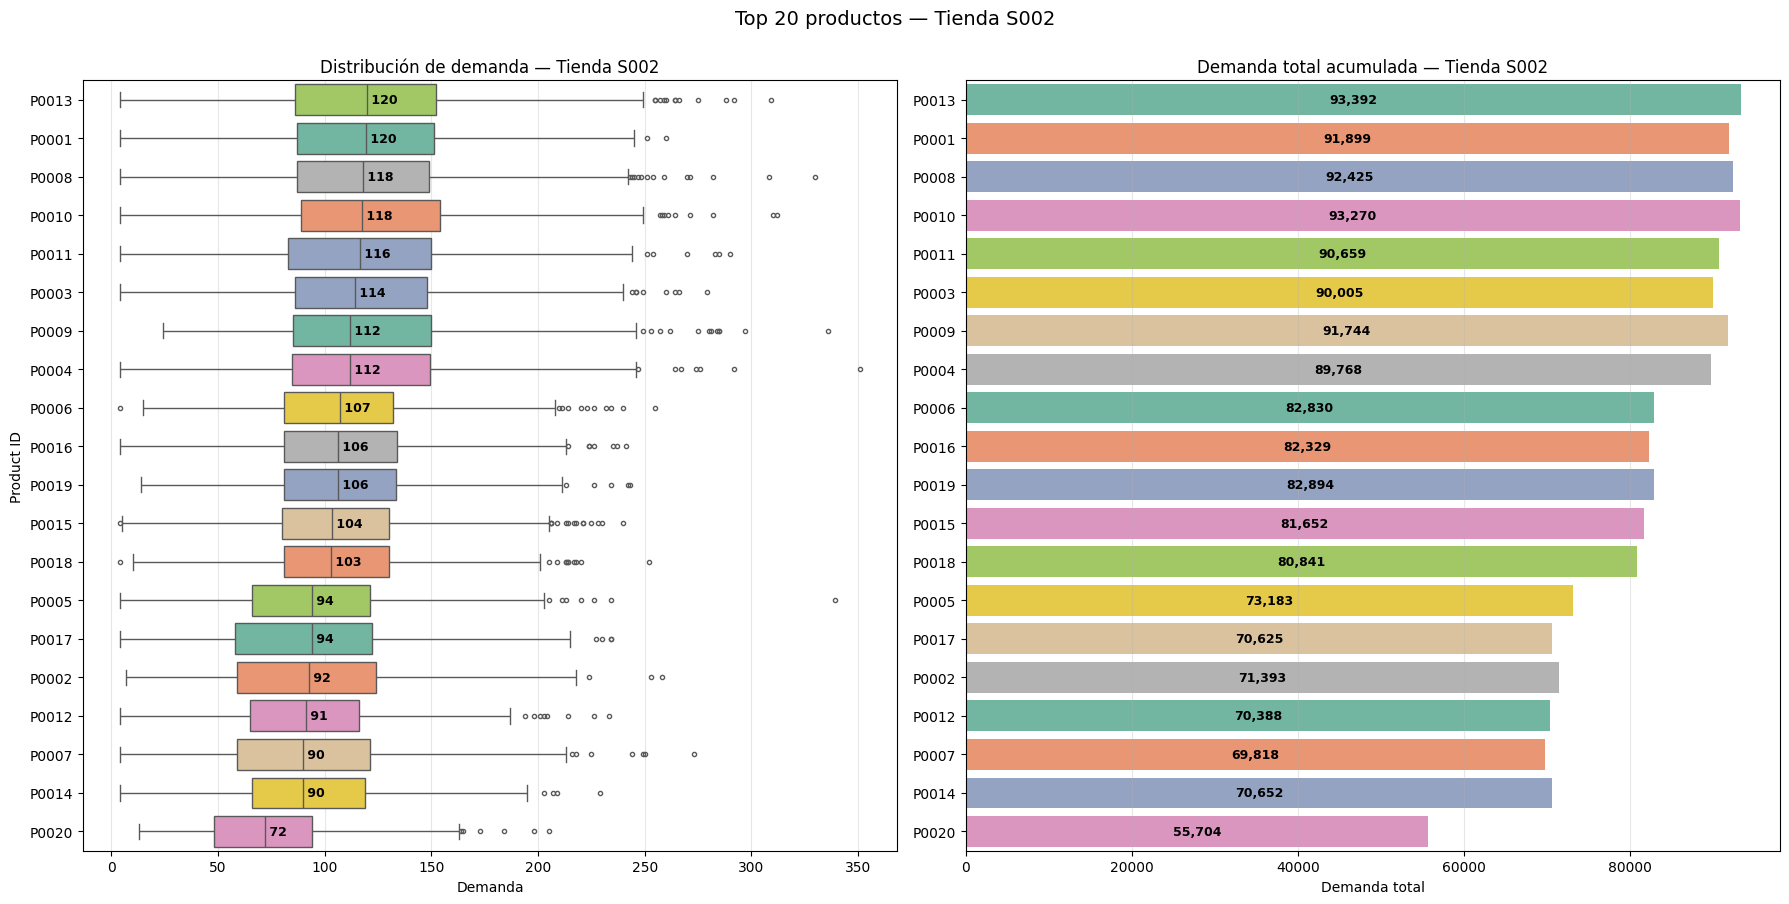

In [60]:
store = 'S002'
df_store = df[df['store_id'] == store]

top20 = (df_store.groupby('product_id')['demand']
         .median().sort_values(ascending=False).head(20).index)
df_top = df_store[df_store['product_id'].isin(top20)]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

sns.boxplot(data=df_top, x='demand', y='product_id',
            hue='product_id', palette='Set2', legend=False,
            order=top20, ax=axes[0], fliersize=3)
axes[0].set_title(f'Distribución de demanda — Tienda {store}', fontsize=12)
axes[0].set_xlabel('Demanda')
axes[0].set_ylabel('Product ID')
axes[0].grid(axis='x', alpha=0.3)

medians = df_top.groupby('product_id')['demand'].median().reindex(top20)
for i, (prod, med) in enumerate(medians.items()):
    axes[0].text(med, i, f' {med:.0f}',
                 va='center', ha='left',
                 fontsize=9, fontweight='bold', color='black')

total_demand = df_top.groupby('product_id')['demand'].sum().reindex(top20)
sns.barplot(x=total_demand.values, y=total_demand.index,
            hue=total_demand.index, palette='Set2', legend=False,
            ax=axes[1])
axes[1].set_title(f'Demanda total acumulada — Tienda {store}', fontsize=12)
axes[1].set_xlabel('Demanda total')
axes[1].set_ylabel('')
axes[1].grid(axis='x', alpha=0.3)

for i, val in enumerate(total_demand.values):
    axes[1].text(val / 2, i, f'{val:,.0f}',
                 va='center', ha='center',
                 fontsize=9, fontweight='bold', color='black')

axes[1].set_xlim(0, total_demand.max() * 1.05)

plt.suptitle(f'Top 20 productos — Tienda {store}', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

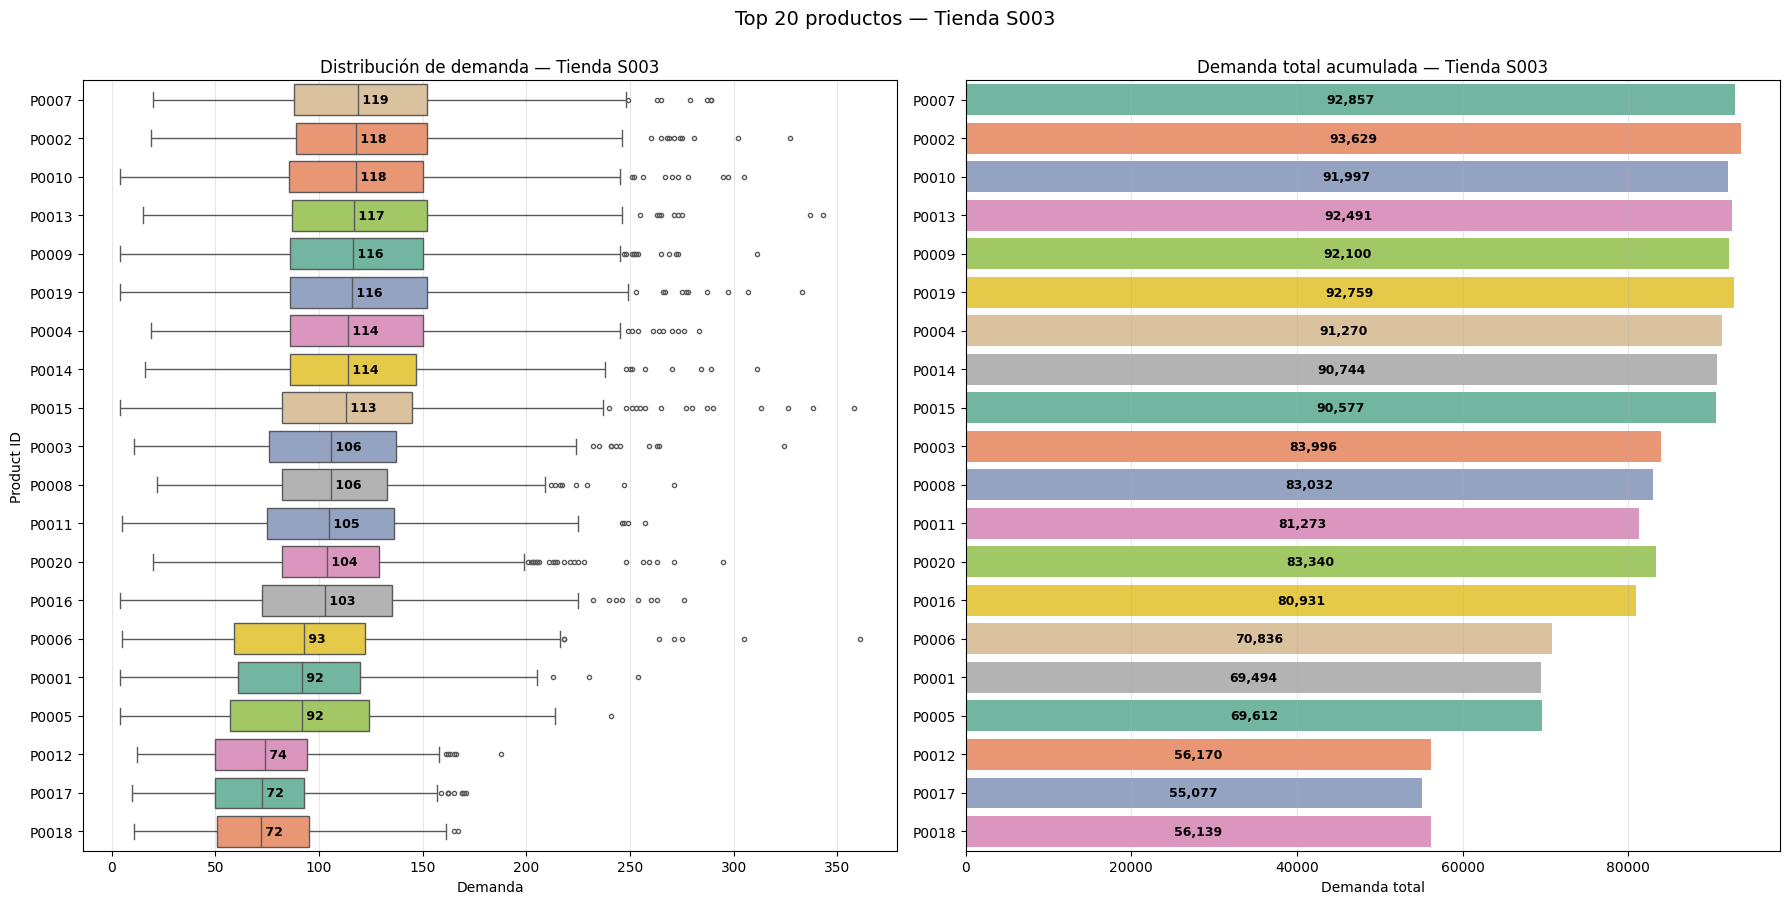

In [61]:
store = 'S003'
df_store = df[df['store_id'] == store]

top20 = (df_store.groupby('product_id')['demand']
         .median().sort_values(ascending=False).head(20).index)
df_top = df_store[df_store['product_id'].isin(top20)]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

sns.boxplot(data=df_top, x='demand', y='product_id',
            hue='product_id', palette='Set2', legend=False,
            order=top20, ax=axes[0], fliersize=3)
axes[0].set_title(f'Distribución de demanda — Tienda {store}', fontsize=12)
axes[0].set_xlabel('Demanda')
axes[0].set_ylabel('Product ID')
axes[0].grid(axis='x', alpha=0.3)

medians = df_top.groupby('product_id')['demand'].median().reindex(top20)
for i, (prod, med) in enumerate(medians.items()):
    axes[0].text(med, i, f' {med:.0f}',
                 va='center', ha='left',
                 fontsize=9, fontweight='bold', color='black')

total_demand = df_top.groupby('product_id')['demand'].sum().reindex(top20)
sns.barplot(x=total_demand.values, y=total_demand.index,
            hue=total_demand.index, palette='Set2', legend=False,
            ax=axes[1])
axes[1].set_title(f'Demanda total acumulada — Tienda {store}', fontsize=12)
axes[1].set_xlabel('Demanda total')
axes[1].set_ylabel('')
axes[1].grid(axis='x', alpha=0.3)

for i, val in enumerate(total_demand.values):
    axes[1].text(val / 2, i, f'{val:,.0f}',
                 va='center', ha='center',
                 fontsize=9, fontweight='bold', color='black')

axes[1].set_xlim(0, total_demand.max() * 1.05)

plt.suptitle(f'Top 20 productos — Tienda {store}', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

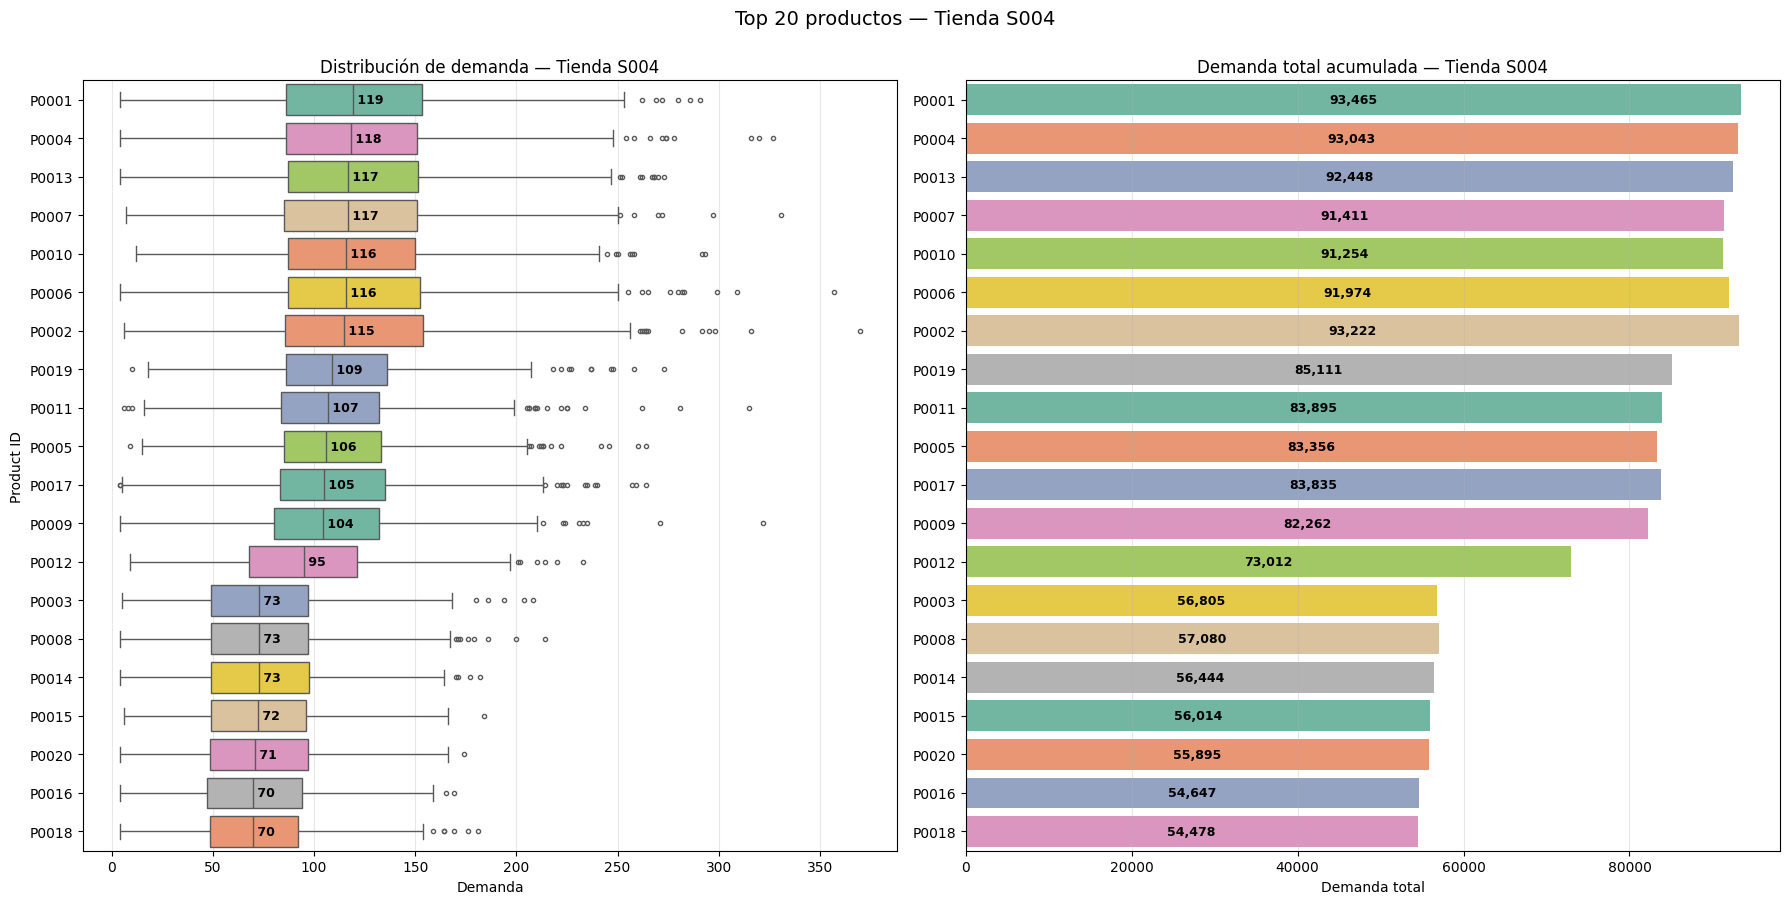

In [62]:
store = 'S004'
df_store = df[df['store_id'] == store]

top20 = (df_store.groupby('product_id')['demand']
         .median().sort_values(ascending=False).head(20).index)
df_top = df_store[df_store['product_id'].isin(top20)]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

sns.boxplot(data=df_top, x='demand', y='product_id',
            hue='product_id', palette='Set2', legend=False,
            order=top20, ax=axes[0], fliersize=3)
axes[0].set_title(f'Distribución de demanda — Tienda {store}', fontsize=12)
axes[0].set_xlabel('Demanda')
axes[0].set_ylabel('Product ID')
axes[0].grid(axis='x', alpha=0.3)

medians = df_top.groupby('product_id')['demand'].median().reindex(top20)
for i, (prod, med) in enumerate(medians.items()):
    axes[0].text(med, i, f' {med:.0f}',
                 va='center', ha='left',
                 fontsize=9, fontweight='bold', color='black')

total_demand = df_top.groupby('product_id')['demand'].sum().reindex(top20)
sns.barplot(x=total_demand.values, y=total_demand.index,
            hue=total_demand.index, palette='Set2', legend=False,
            ax=axes[1])
axes[1].set_title(f'Demanda total acumulada — Tienda {store}', fontsize=12)
axes[1].set_xlabel('Demanda total')
axes[1].set_ylabel('')
axes[1].grid(axis='x', alpha=0.3)

for i, val in enumerate(total_demand.values):
    axes[1].text(val / 2, i, f'{val:,.0f}',
                 va='center', ha='center',
                 fontsize=9, fontweight='bold', color='black')

axes[1].set_xlim(0, total_demand.max() * 1.05)

plt.suptitle(f'Top 20 productos — Tienda {store}', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

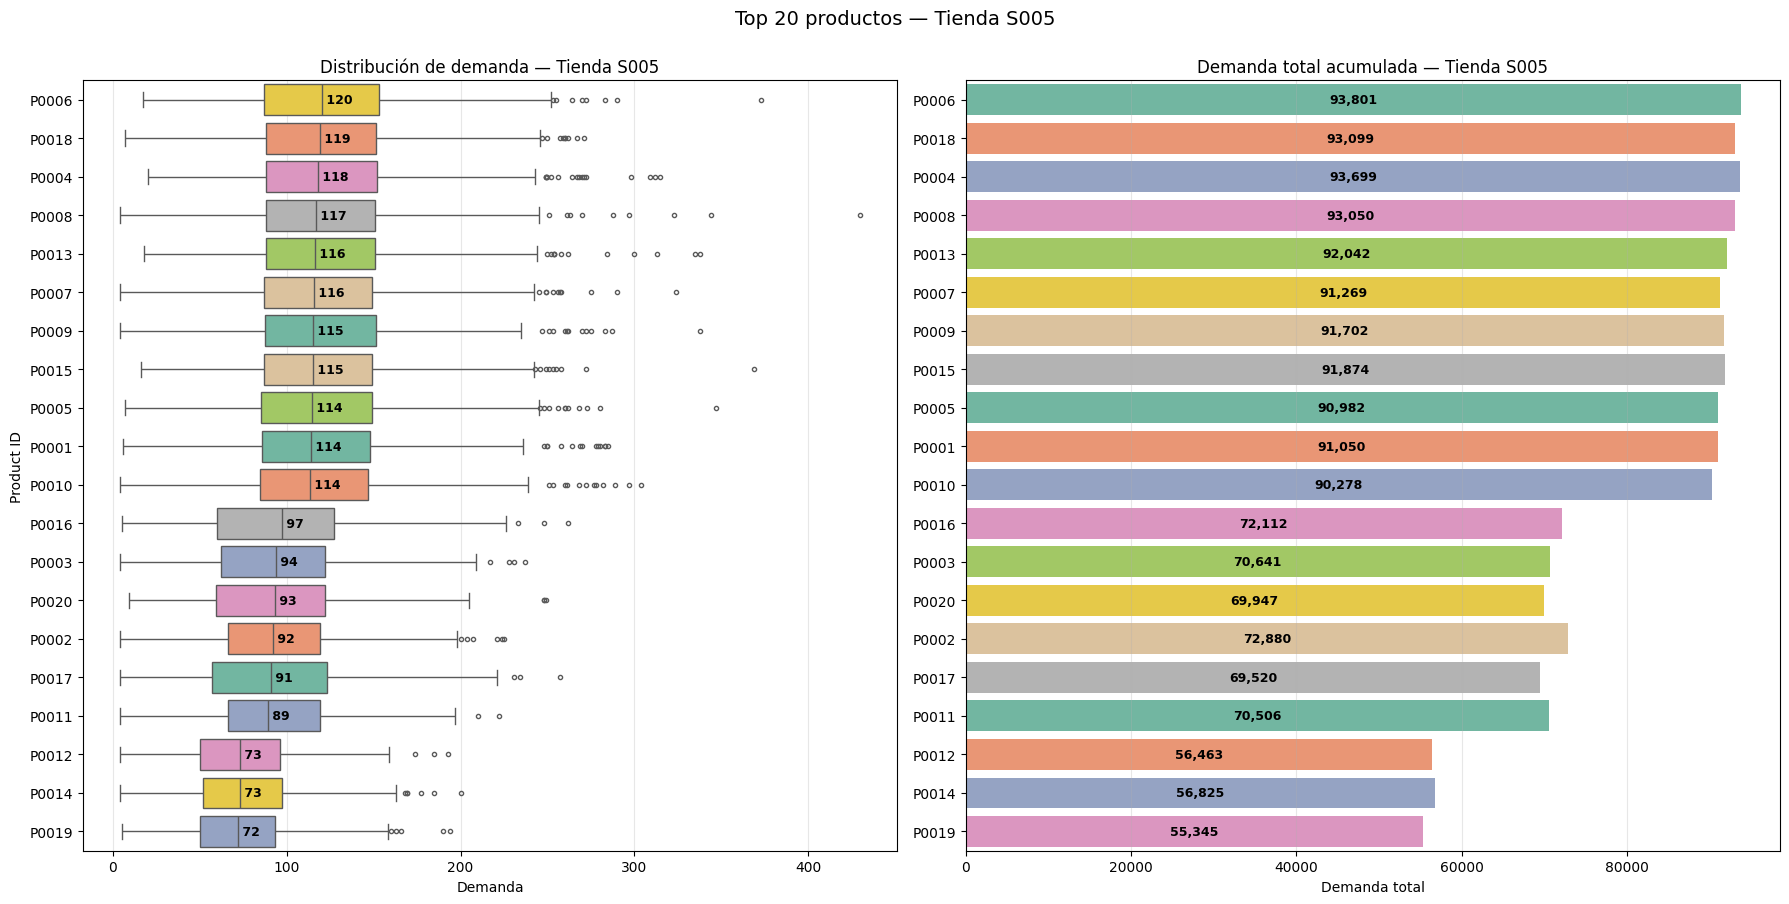

In [63]:
store = 'S005'
df_store = df[df['store_id'] == store]

top20 = (df_store.groupby('product_id')['demand']
         .median().sort_values(ascending=False).head(20).index)
df_top = df_store[df_store['product_id'].isin(top20)]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

sns.boxplot(data=df_top, x='demand', y='product_id',
            hue='product_id', palette='Set2', legend=False,
            order=top20, ax=axes[0], fliersize=3)
axes[0].set_title(f'Distribución de demanda — Tienda {store}', fontsize=12)
axes[0].set_xlabel('Demanda')
axes[0].set_ylabel('Product ID')
axes[0].grid(axis='x', alpha=0.3)

medians = df_top.groupby('product_id')['demand'].median().reindex(top20)
for i, (prod, med) in enumerate(medians.items()):
    axes[0].text(med, i, f' {med:.0f}',
                 va='center', ha='left',
                 fontsize=9, fontweight='bold', color='black')

total_demand = df_top.groupby('product_id')['demand'].sum().reindex(top20)
sns.barplot(x=total_demand.values, y=total_demand.index,
            hue=total_demand.index, palette='Set2', legend=False,
            ax=axes[1])
axes[1].set_title(f'Demanda total acumulada — Tienda {store}', fontsize=12)
axes[1].set_xlabel('Demanda total')
axes[1].set_ylabel('')
axes[1].grid(axis='x', alpha=0.3)

for i, val in enumerate(total_demand.values):
    axes[1].text(val / 2, i, f'{val:,.0f}',
                 va='center', ha='center',
                 fontsize=9, fontweight='bold', color='black')

axes[1].set_xlim(0, total_demand.max() * 1.05)

plt.suptitle(f'Top 20 productos — Tienda {store}', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

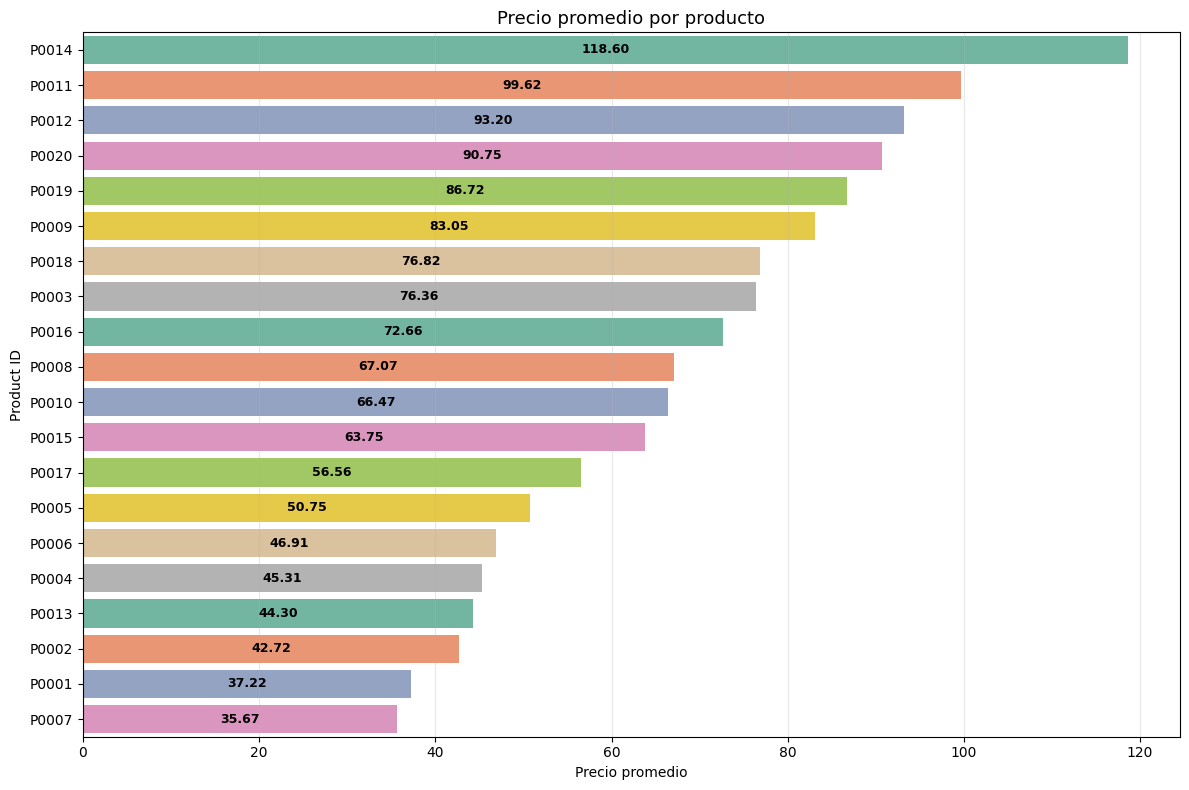

In [64]:
fig, ax = plt.subplots(figsize=(12, 8))

precio_promedio = (df.groupby('product_id')['price']
                   .mean().sort_values(ascending=False))

sns.barplot(x=precio_promedio.values, y=precio_promedio.index,
            hue=precio_promedio.index, palette='Set2', legend=False, ax=ax)

ax.set_title('Precio promedio por producto', fontsize=13)
ax.set_xlabel('Precio promedio')
ax.set_ylabel('Product ID')
ax.grid(axis='x', alpha=0.3)

for i, val in enumerate(precio_promedio.values):
    ax.text(val / 2, i, f'{val:.2f}',
            va='center', ha='center',
            fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

             precio_promedio  demanda_promedio  demanda_total
category                                                     
Groceries              51.66            120.98        3677684
Clothing               71.52            112.62        1369456
Furniture             121.51             73.58        1006590
Toys                   26.91             92.61         985338
Electronics            83.17             97.48         889036


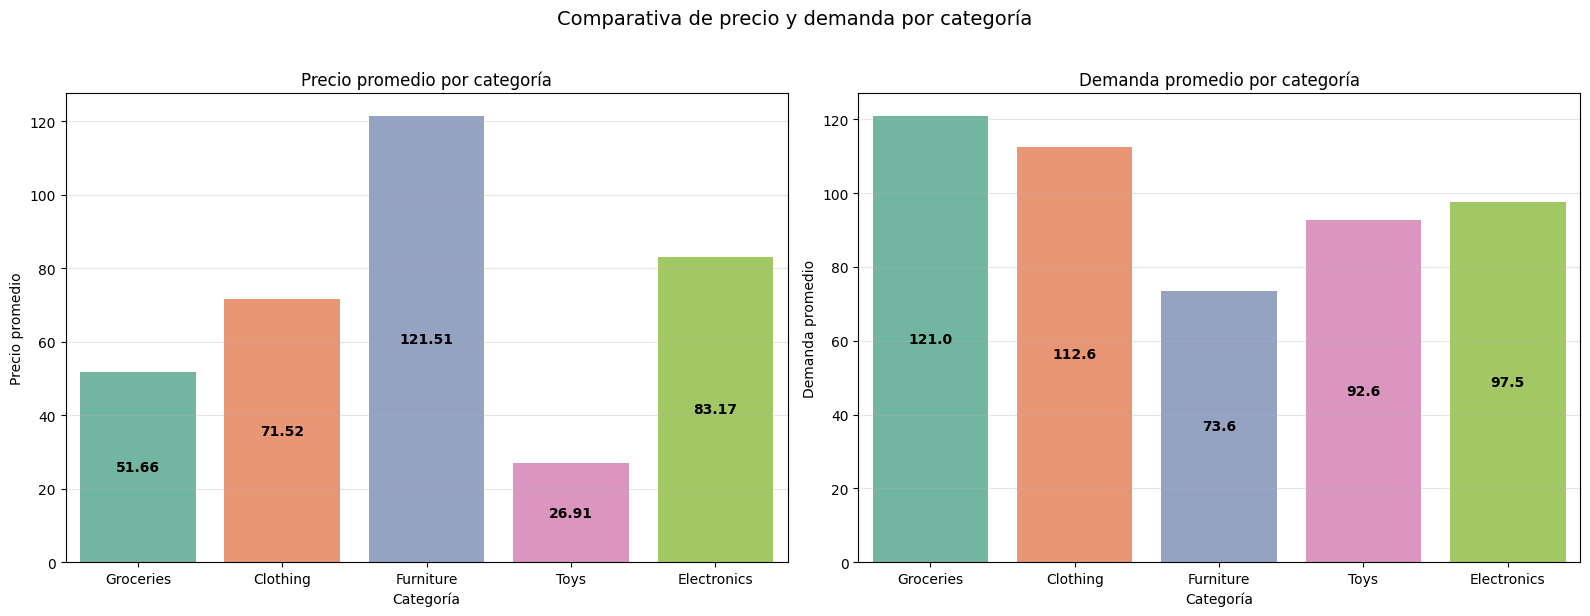

In [65]:
resumen_cat = (df.groupby('category')
               .agg(precio_promedio=('price', 'mean'),
                    demanda_promedio=('demand', 'mean'),
                    demanda_total=('demand', 'sum'))
               .sort_values('demanda_total', ascending=False))

print(resumen_cat.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precio promedio por categoría
sns.barplot(x=resumen_cat.index, y=resumen_cat['precio_promedio'],
            hue=resumen_cat.index, palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Precio promedio por categoría', fontsize=12)
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Precio promedio')
axes[0].grid(axis='y', alpha=0.3)
for i, val in enumerate(resumen_cat['precio_promedio'].values):
    axes[0].text(i, val / 2, f'{val:.2f}',
                 ha='center', va='center',
                 fontsize=10, fontweight='bold', color='black')

# Demanda promedio por categoría
sns.barplot(x=resumen_cat.index, y=resumen_cat['demanda_promedio'],
            hue=resumen_cat.index, palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Demanda promedio por categoría', fontsize=12)
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Demanda promedio')
axes[1].grid(axis='y', alpha=0.3)
for i, val in enumerate(resumen_cat['demanda_promedio'].values):
    axes[1].text(i, val / 2, f'{val:.1f}',
                 ha='center', va='center',
                 fontsize=10, fontweight='bold', color='black')

plt.suptitle('Comparativa de precio y demanda por categoría',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Producto con MAYOR demanda total: P0009 (demanda=450,324, precio=83.05)
Producto con MAYOR precio promedio: P0014 (precio=118.60, demanda=364,335)


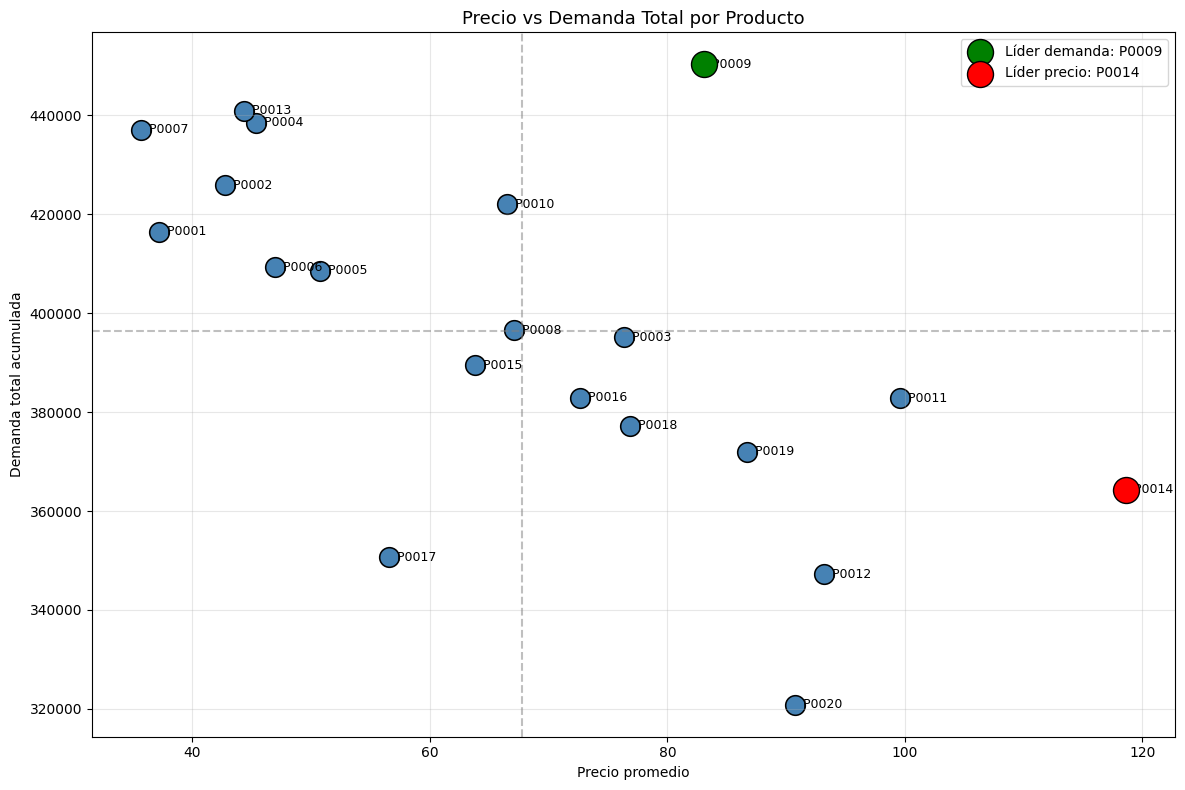

In [66]:
resumen_prod = (df.groupby('product_id')
                .agg(precio_promedio=('price', 'mean'),
                     demanda_promedio=('demand', 'mean'),
                     demanda_total=('demand', 'sum'))
                .reset_index())

# Identificar líderes
lider_demanda = resumen_prod.loc[resumen_prod['demanda_total'].idxmax()]
lider_precio = resumen_prod.loc[resumen_prod['precio_promedio'].idxmax()]

print(f"Producto con MAYOR demanda total: {lider_demanda['product_id']} "
      f"(demanda={lider_demanda['demanda_total']:,.0f}, "
      f"precio={lider_demanda['precio_promedio']:.2f})")
print(f"Producto con MAYOR precio promedio: {lider_precio['product_id']} "
      f"(precio={lider_precio['precio_promedio']:.2f}, "
      f"demanda={lider_precio['demanda_total']:,.0f})")

# Scatter precio vs demanda
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=resumen_prod, x='precio_promedio', y='demanda_total',
                s=200, color='steelblue', edgecolor='black', ax=ax)

# Etiquetar cada punto con el product_id
for _, row in resumen_prod.iterrows():
    ax.text(row['precio_promedio'], row['demanda_total'],
            f"  {row['product_id']}", fontsize=9, va='center')

# Resaltar líderes en rojo y verde
ax.scatter(lider_demanda['precio_promedio'], lider_demanda['demanda_total'],
           s=350, color='green', edgecolor='black',
           label=f"Líder demanda: {lider_demanda['product_id']}", zorder=5)
ax.scatter(lider_precio['precio_promedio'], lider_precio['demanda_total'],
           s=350, color='red', edgecolor='black',
           label=f"Líder precio: {lider_precio['product_id']}", zorder=5)

# Líneas de promedio para dividir en cuadrantes
ax.axvline(resumen_prod['precio_promedio'].mean(),
           color='gray', linestyle='--', alpha=0.5)
ax.axhline(resumen_prod['demanda_total'].mean(),
           color='gray', linestyle='--', alpha=0.5)

ax.set_title('Precio vs Demanda Total por Producto', fontsize=13)
ax.set_xlabel('Precio promedio')
ax.set_ylabel('Demanda total acumulada')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

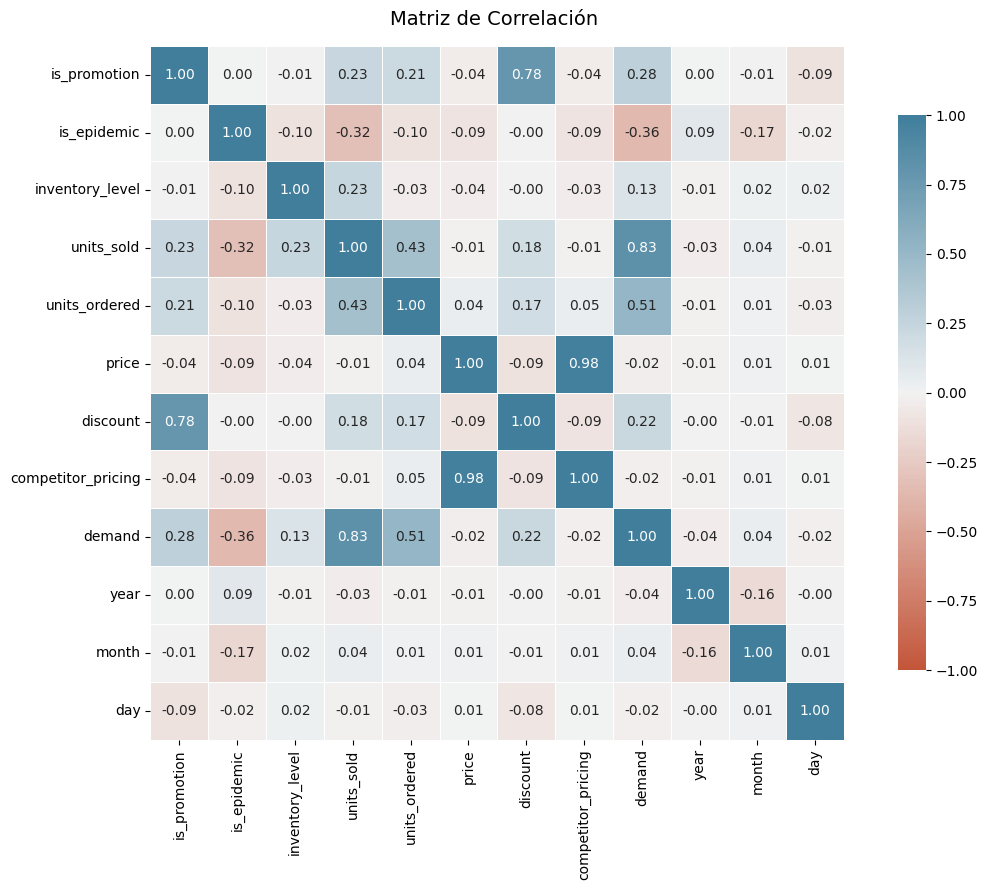

In [67]:
df_corr = df.copy()
df_corr['is_promotion'] = df_corr['is_promotion'].cat.codes
df_corr['is_epidemic'] = df_corr['is_epidemic'].cat.codes

corr_matrix = df_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    annot=True,
    fmt='.2f',
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Matriz de Correlación ', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


## 5. Data Transformation — Producto P009 y tratamiento de outliers

En esta parte se prepara el subconjunto del producto **P0009**. Como no se está reemplazando nulos, la transformación principal consiste en identificar y retirar outliers de demanda mediante IQR.


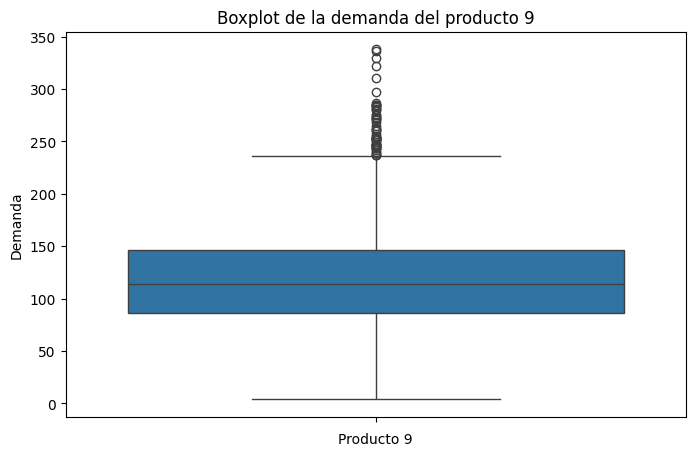

In [68]:
#Limpiar data a solo tener P09
df_producto_9 = df[df["product_id"] == "P0009"]
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_producto_9,
    y="demand"
)

plt.title("Boxplot de la demanda del producto 9")
plt.ylabel("Demanda")
plt.xlabel("Producto 9")

plt.show()

In [69]:
Q1 = df_producto_9["demand"].quantile(0.25)
Q3 = df_producto_9["demand"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

# Crear columna que indique si es outlier
df_producto_9["Outlier"] = (
    (df_producto_9["demand"] < limite_inferior) |
    (df_producto_9["demand"] > limite_superior)
)

# Ver cuántos outliers hay
print(df_producto_9["Outlier"].value_counts())

Q1: 86.0
Q3: 146.0
IQR: 60.0
Límite inferior: -4.0
Límite superior: 236.0
Outlier
False    3742
True       58
Name: count, dtype: int64


In [70]:
# Crear un nuevo dataframe sin outliers
df_producto_9_sin_outliers = df_producto_9[df_producto_9["Outlier"] == False].copy()

# Verificar cantidad de registros antes y después
print("Registros originales:", len(df_producto_9))
print("Registros sin outliers:", len(df_producto_9_sin_outliers))
print("Registros eliminados:", len(df_producto_9) - len(df_producto_9_sin_outliers))

Registros originales: 3800
Registros sin outliers: 3742
Registros eliminados: 58


## 6. Insights — análisis del Producto P009

Esta sección queda centrada solo en el análisis del producto **P0009** después del tratamiento de outliers.


In [71]:
print(df_producto_9_sin_outliers["demand"].describe())

count    3742.000000
mean      116.230625
std        42.523890
min         4.000000
25%        86.000000
50%       113.000000
75%       144.000000
max       236.000000
Name: demand, dtype: float64


In [72]:
df_producto_9_sin_outliers["demand"].mode()

0    101
Name: demand, dtype: int64

In [73]:
df_producto_9_sin_outliers["demand"].median()

np.float64(113.0)

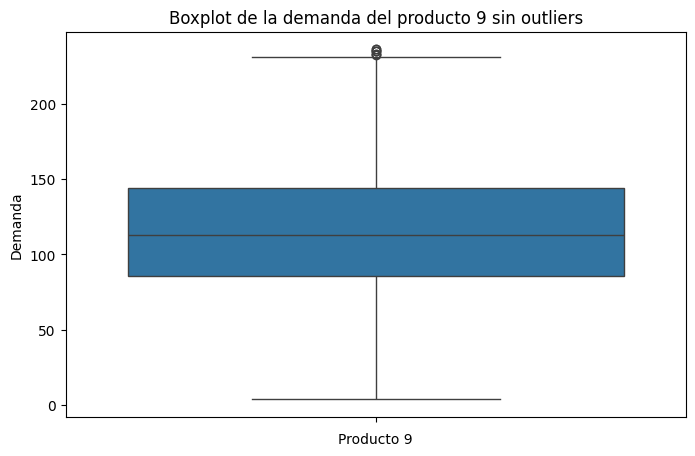

In [74]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_producto_9_sin_outliers,
    y="demand"
)

plt.title("Boxplot de la demanda del producto 9 sin outliers")
plt.ylabel("Demanda")
plt.xlabel("Producto 9")

plt.show()

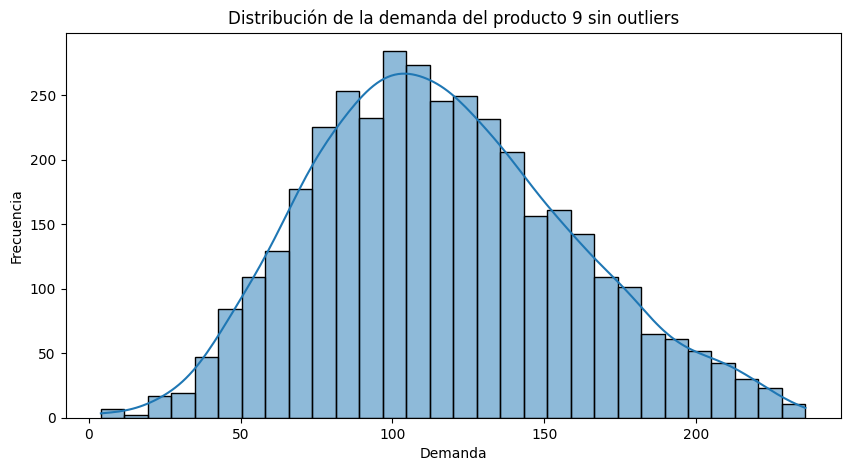

In [75]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_producto_9_sin_outliers,
    x="demand",
    bins=30,
    kde=True
)

plt.title("Distribución de la demanda del producto 9 sin outliers")
plt.xlabel("Demanda")
plt.ylabel("Frecuencia")

plt.show()

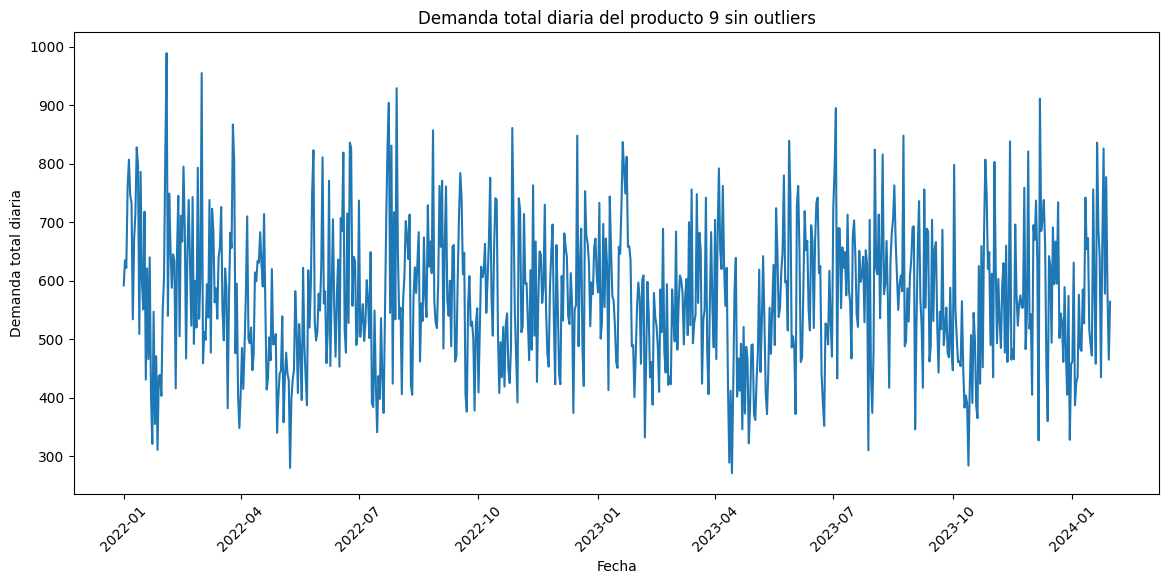

In [76]:
df_producto_9_sin_outliers["date"] = pd.to_datetime(df_producto_9_sin_outliers["date"])

demanda_diaria = df_producto_9_sin_outliers.groupby("date")["demand"].sum().reset_index()

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=demanda_diaria,
    x="date",
    y="demand"
)

plt.title("Demanda total diaria del producto 9 sin outliers")
plt.xlabel("Fecha")
plt.ylabel("Demanda total diaria")
plt.xticks(rotation=45)

plt.show()

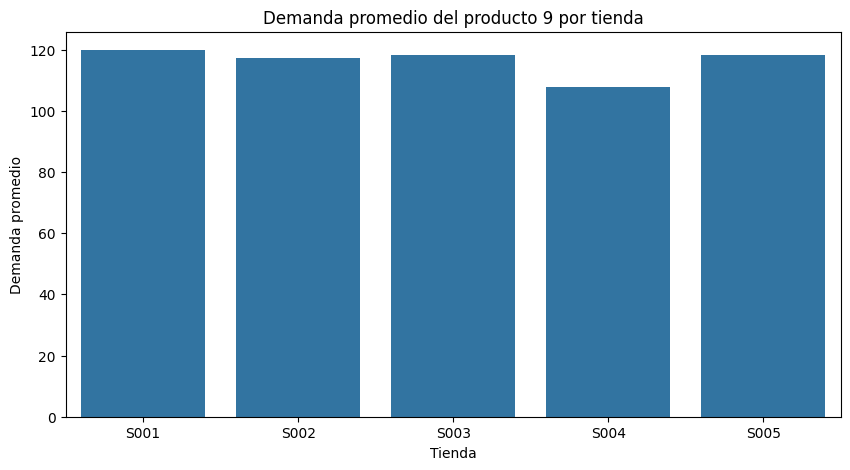

In [77]:
demanda_tienda = df_producto_9_sin_outliers.groupby("store_id")["demand"].mean().reset_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    data=demanda_tienda,
    x="store_id",
    y="demand"
)

plt.title("Demanda promedio del producto 9 por tienda")
plt.xlabel("Tienda")
plt.ylabel("Demanda promedio")

plt.show()